In [130]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import torch 
from torch import nn, optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split
import copy
import mytools
import os, random


# Print and store device being used
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


# Define important parameters

In [454]:
# Number of class in invariant mass used by the adversary
Num_classes = 10
# Hyper-parameter for adversarial training of the classifier
lambda_ = 6.0

run = 7


def seed_everything(seed: int = 0):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(int(56))

# Load and setup the data

In [455]:
# Read tritrig, wab, phiKK, and data files
df_tritrig = pd.read_pickle('/Users/mghrear/data/ML_data/patch/2021_v9_pass5_tritrig_limited.pk')
df_tritrig['PhiKK'] = 0.0
df_phiKK = pd.read_pickle('/Users/mghrear/data/ML_data/patch/2021_v9_pass5_phiKK_limited.pk')
df_phiKK['PhiKK'] = 1.0
df_wab = pd.read_pickle('/Users/mghrear/data/ML_data/patch/2021_v9_pass5_wab_limited.pk')
df_wab['PhiKK'] = 0.0 # Add label


print("tritrig: ", len(df_tritrig))
print("phiKK: ", len(df_phiKK))
print("wab: ", len(df_wab))


tritrig:  120739
phiKK:  4086
wab:  6596


In [456]:
# Make Training set with 20000 tritrig, 4000 phiKK, 4000 wab
tritrig_train = df_tritrig[0:20000]
wab_train = df_wab[0:3000]
phiKK_train = df_phiKK[0:3000]

# Combine and shuffle all training data
df_train = pd.concat([tritrig_train, phiKK_train, wab_train], ignore_index=True, sort=False)
df_train = df_train.sample(frac=1, random_state=42).reset_index(drop=True)

# Get edges in invariant mass classes for one-hot encoding
# To be used for adverserial labels
# The edges are chosen such that each bin has equal number of background events
one_hot_edges = mytools.get_one_hot_edges(mytools.get_InvM( pd.concat([df_tritrig, df_wab], ignore_index=True, sort=False) ), n_bins=Num_classes)

# Split the training data into training and validation sets
df_train, df_val = train_test_split(df_train, test_size=0.33, random_state=42)

# Make X and y for training and validation sets
# the adverserial network has its own labels
X_train = df_train.drop(columns=['PhiKK'])
y_train = df_train['PhiKK']
y_adv_train = mytools.get_adv_labels( mytools.get_InvM(df_train), one_hot_edges)
X_val = df_val.drop(columns=['PhiKK'])
y_val = df_val['PhiKK']
y_adv_val = mytools.get_adv_labels( mytools.get_InvM(df_val), one_hot_edges)

# Make testing set with remaining events
tritrig_test = df_tritrig[20000:]
tritrig_test['type']= 'tritrig'
wab_test = df_wab[3000:]
wab_test['type']= 'wab'
phiKK_test = df_phiKK[3000:]
phiKK_test['type']= 'phiKK'

df_test = pd.concat([tritrig_test, phiKK_test,wab_test], ignore_index=True, sort=False)
df_test = df_test.sample(frac=1, random_state=42).reset_index(drop=True) # Now shuffle the combined dataframe

X_test = df_test.drop(columns=['PhiKK','type'])
y_test = df_test['PhiKK']
y_adv_test = mytools.get_adv_labels( mytools.get_InvM(df_test), one_hot_edges)

df_test["InvM"] = mytools.get_InvM(df_test) 



/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_31787/1157922432.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tritrig_test['type']= 'tritrig'
/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_31787/1157922432.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wab_test['type']= 'wab'
/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_31787/1157922432.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_inde

## Setup dataloaders

In [457]:
bsize = 2000

# Convert to tensor dataset and dataloader
train_dataset = TensorDataset(torch.from_numpy(X_train.to_numpy().astype(np.float32))  , torch.from_numpy(y_train.to_numpy().astype(np.float32)).unsqueeze(1)  )
train_loader = DataLoader(train_dataset, batch_size=bsize, shuffle=True)

val_dataset = TensorDataset(torch.from_numpy(X_val.to_numpy().astype(np.float32))  , torch.from_numpy(y_val.to_numpy().astype(np.float32)).unsqueeze(1)  )
val_loader = DataLoader(val_dataset, batch_size=bsize, shuffle=True)

test_dataset = TensorDataset(torch.from_numpy(X_test.to_numpy().astype(np.float32)))
test_loader = DataLoader(test_dataset, batch_size=bsize, shuffle=False)


## Initialize model, objective function, and optimizer

In [458]:
clas = mytools.Classifier(in_features=X_train.shape[1]).to(device)
criterion_clas = nn.BCEWithLogitsLoss()
optimizer_clas = optim.Adam(clas.parameters(), lr=1e-5)
scheduler_clas = torch.optim.lr_scheduler.ExponentialLR(optimizer_clas, gamma=0.9999)


## Pre-train the classifier

In [459]:
# Implement early stopping in training loop
# Stop if validation loss has not decreased for the last [patience] epochs
# The model with the lowest loss is stored
patience = 10

Training_losses = np.array([])
Validation_losses = np.array([])

epochs = 4000
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    
    Training_losses = np.append(Training_losses, mytools.train_clas(train_loader, clas, criterion_clas, optimizer_clas, scheduler_clas, device))
    Validation_losses = np.append(Validation_losses, mytools.validate_clas(val_loader, clas, criterion_clas, device))
    
    # Keep a running copy of the model with the lowest loss
    if Validation_losses[-1] == np.min(Validation_losses):
        final_classifier = copy.deepcopy(clas)
    
    if len(Validation_losses) > patience:
        if np.sum((Validation_losses[-1*np.arange(patience)-1] - Validation_losses[-1*np.arange(patience)-2]) < 0) == 0:
            print("Stopping early!")
            break
            
print("Done!")

Epoch 1
-------------------------------
Training loss: 0.644811
Validation loss: 0.674308 

Epoch 2
-------------------------------
Training loss: 0.617867
Validation loss: 0.653311 

Epoch 3
-------------------------------
Training loss: 0.603035
Validation loss: 0.639935 

Epoch 4
-------------------------------
Training loss: 0.595751
Validation loss: 0.624189 

Epoch 5
-------------------------------
Training loss: 0.585060
Validation loss: 0.615744 

Epoch 6
-------------------------------
Training loss: 0.578326
Validation loss: 0.598658 

Epoch 7
-------------------------------
Training loss: 0.571515
Validation loss: 0.577901 

Epoch 8
-------------------------------
Training loss: 0.564167
Validation loss: 0.568488 

Epoch 9
-------------------------------
Training loss: 0.559521
Validation loss: 0.560595 

Epoch 10
-------------------------------
Training loss: 0.554924
Validation loss: 0.551430 

Epoch 11
-------------------------------
Training loss: 0.553078
Validation los

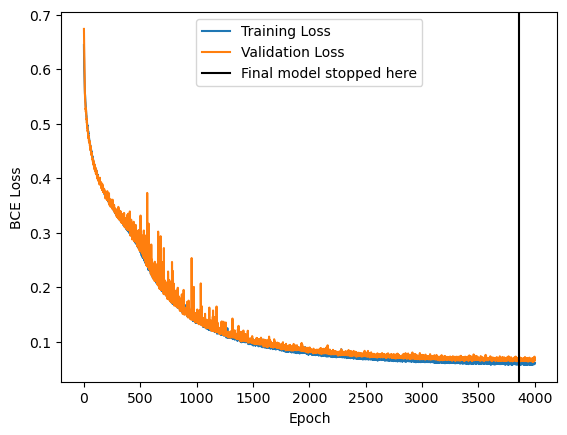

In [460]:
# Plot Training and Validation Loss
# Indicate where the final model stopped training

best_epoch = np.argmin(Validation_losses)+1

plt.plot(np.arange(len(Training_losses))+1,Training_losses,label="Training Loss")
plt.plot(np.arange(len(Validation_losses))+1,Validation_losses,label="Validation Loss")
plt.axvline(best_epoch,label="Final model stopped here",color='k')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
#plt.yscale('log')
plt.legend()

Test AUROC: 0.9935


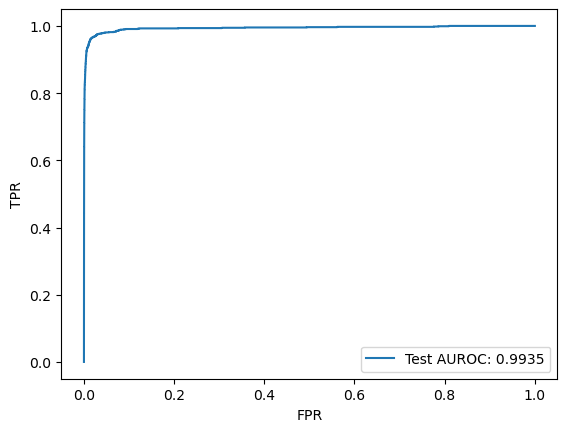

In [461]:
# Now test the pretrained model
test_pred = mytools.test_clas(test_loader, final_classifier, device)
test_pred=torch.sigmoid(torch.tensor(test_pred)).numpy()


fpr, tpr, thresholds = sklearn.metrics.roc_curve(y_test, test_pred, pos_label=1)
auc_test = sklearn.metrics.auc(fpr, tpr)
print(f'Test AUROC: {auc_test:0.4f}')

plt.plot(fpr, tpr, label=f'Test AUROC: {auc_test:0.4f}')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()

In [462]:
# Store the pretrained classifier labels
df_test["Class_pre"] = test_pred

# Save the pretrained classifier model
#torch.save(final_classifier.state_dict(), "/Users/mghrear/data/ML_data/patch/pretrained_classifier_2021_v9_pass5_run"+str(run)+"_limited.pt")


# Setup the adversary model

## Initialize model, objective function, and optimizer

In [463]:
adv = mytools.Adversary_small(n_classes=Num_classes).to(device)
criterion_adv = nn.CrossEntropyLoss(reduction='none')  # returns loss per sample so we can weight it
opt_adv = torch.optim.Adam(adv.parameters(), lr=1e-5)
scheduler_adv = torch.optim.lr_scheduler.ExponentialLR(opt_adv, gamma=0.999)


## Setup dataloaders

In [464]:
# Convert to tensor dataset and dataloader

# the structure is: feature, adversary label, weight
# The wight is 1 for tritrig and wab, and 0 for phiKK, to prevent the adversary from learning on phiKK events

train_adv_dataset = TensorDataset(torch.from_numpy(X_train.to_numpy() .astype(np.float32))  , torch.from_numpy(y_adv_train), (torch.from_numpy(y_train.to_numpy().astype(np.float32))==0).float())
train_adv_loader = DataLoader(train_adv_dataset, batch_size=bsize, shuffle=True)

val_adv_dataset = TensorDataset(torch.from_numpy(X_val.to_numpy() .astype(np.float32))  , torch.from_numpy(y_adv_val), (torch.from_numpy(y_val.to_numpy().astype(np.float32))==0).float() )
val_adv_loader = DataLoader(val_adv_dataset, batch_size=bsize, shuffle=True)

# Weights are not relavent for testing
test_adv_dataset = TensorDataset(torch.from_numpy(X_test.to_numpy() .astype(np.float32))  , torch.from_numpy(y_adv_test))
test_adv_loader = DataLoader(test_adv_dataset, batch_size=bsize, shuffle=True)

## Pre-train the adversary leaving classifier weights fixed

In [465]:
# Implement early stopping in training loop
# Stop if validation loss has not decreased for the last [patience] epochs
# The model with the lowest loss is stored


Training_losses = np.array([])
Validation_losses = np.array([])

epochs = 1000
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    
    Training_losses = np.append(Training_losses, mytools.train_adv(train_adv_loader, final_classifier, adv, criterion_adv, opt_adv, scheduler_adv, device))
    Validation_losses = np.append(Validation_losses, mytools.validate_adv(val_adv_loader, final_classifier, adv, criterion_adv, device))
    
    # Keep a running copy of the model with the lowest loss
    if Validation_losses[-1] == np.min(Validation_losses):
        final_adv = copy.deepcopy(adv)

print("Done!")

Epoch 1
-------------------------------
Training loss: 2.811880
Validation loss: 2.836863 

Epoch 2
-------------------------------
Training loss: 2.802046
Validation loss: 2.824789 

Epoch 3
-------------------------------
Training loss: 2.792127
Validation loss: 2.811531 

Epoch 4
-------------------------------
Training loss: 2.781738
Validation loss: 2.809898 

Epoch 5
-------------------------------
Training loss: 2.771753
Validation loss: 2.793807 

Epoch 6
-------------------------------
Training loss: 2.765098
Validation loss: 2.779378 

Epoch 7
-------------------------------
Training loss: 2.752501
Validation loss: 2.778391 

Epoch 8
-------------------------------
Training loss: 2.746561
Validation loss: 2.762212 

Epoch 9
-------------------------------
Training loss: 2.736802
Validation loss: 2.761753 

Epoch 10
-------------------------------
Training loss: 2.727952
Validation loss: 2.752485 

Epoch 11
-------------------------------
Training loss: 2.720414
Validation los

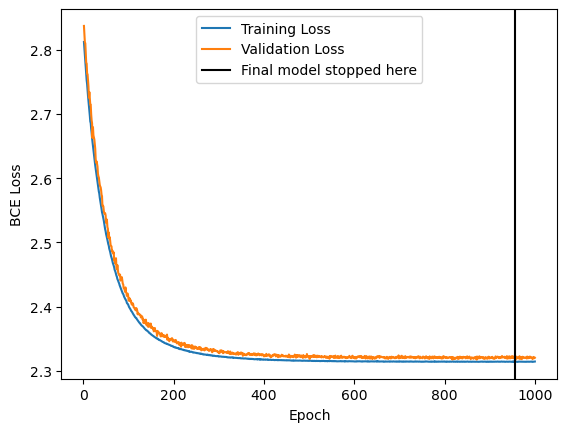

In [466]:
# Plot Training and Validation Loss
# Indicate where the final model stopped training

best_epoch = np.argmin(Validation_losses)+1

plt.plot(np.arange(len(Training_losses))+1,Training_losses,label="Training Loss")
plt.plot(np.arange(len(Validation_losses))+1,Validation_losses,label="Validation Loss")
plt.axvline(best_epoch,label="Final model stopped here",color='k')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.legend()

## Test the pre-trained adversary

class 0 test auc score: 0.5010853552872472
class 1 test auc score: 0.49927485116312803
class 2 test auc score: 0.5020058205655114
class 3 test auc score: 0.5024123804508138
class 4 test auc score: 0.5066150867220993
class 5 test auc score: 0.49740110015092437
class 6 test auc score: 0.4985083938512774
class 7 test auc score: 0.49617833047309123
class 8 test auc score: 0.5009364421130139
class 9 test auc score: 0.5014299886530671
average score:  0.5005847749430175


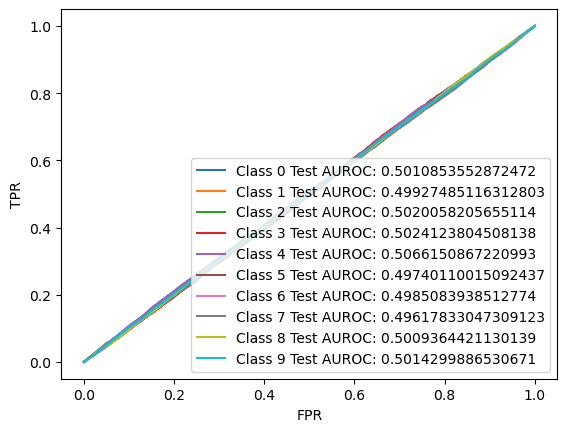

In [467]:

adv_test_pred = mytools.test_adv(test_adv_loader, final_classifier, final_adv, Num_classes, device)
adv_test_pred = torch.softmax(torch.tensor(adv_test_pred),dim=1).numpy()
score=0

for i in range(adv_test_pred.shape[1]):
    fpr, tpr, thresholds = sklearn.metrics.roc_curve(y_adv_test[:,i], adv_test_pred[:,i], pos_label=1)
    auc_test = sklearn.metrics.auc(fpr, tpr)
    print("class " + str(i)+ " test auc score: " + str(auc_test))

    plt.plot(fpr, tpr, label='Class '+str(i)+' Test AUROC: '+str(auc_test))
    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.legend()

    score += auc_test

print("average score: ", score/adv_test_pred.shape[1])

# Train full adverserial neural network

# Setup dataloaders

In [468]:
# the structure is: feature, classifier label, adversary label, weight
# The wight is 1 for tritrig and wab, and 0 for phiKK, to prevent the adversary from learning on phiKK events

train_full_dataset = TensorDataset(torch.from_numpy(X_train.to_numpy().astype(np.float32))  , torch.from_numpy(y_train.to_numpy().astype(np.float32)).unsqueeze(1), torch.from_numpy(y_adv_train),  (torch.from_numpy(y_train.to_numpy().astype(np.float32))==0).float())
train_full_loader = DataLoader(train_full_dataset, batch_size=bsize, shuffle=True)

val_full_dataset = TensorDataset(torch.from_numpy(X_val.to_numpy().astype(np.float32))  , torch.from_numpy(y_val.to_numpy().astype(np.float32)).unsqueeze(1),  torch.from_numpy(y_adv_val),  (torch.from_numpy(y_val.to_numpy().astype(np.float32))==0).float())
val_full_loader = DataLoader(val_full_dataset, batch_size=bsize, shuffle=True)


## Define loss functions

In [469]:
BCE_loss = nn.BCEWithLogitsLoss()
CE_loss = nn.CrossEntropyLoss(reduction='none') # returns loss per sample so we can weight it

def full_loss(output_clas, output_adv, target_clas, target_adv, w, lambda_):

    loss1 = BCE_loss(output_clas, target_clas )  # classification loss
    sample_losses2 = CE_loss(output_adv, target_adv)  # adversarial losses, since we set reduction='none', this is now a vector of losses, one per sample in the batch

    # Weighted mean loss over non-zero weights
    nonzero = w > 0
    loss2 = (sample_losses2[nonzero] * w[nonzero]).sum() / w[nonzero].sum()

    loss = loss1 - lambda_*loss2

    return loss
    


## Setup optimizers

In [470]:
optimizer_clas = optim.Adam(final_classifier.parameters(), lr=1e-7,betas=(0.9, 0.999))
optimizer_adv = optim.Adam(final_adv.parameters(), lr=2e-6,betas=(0.9, 0.999))

scheduler_clas = torch.optim.lr_scheduler.ExponentialLR(optimizer_clas, gamma=0.999)
scheduler_adv = torch.optim.lr_scheduler.ExponentialLR(optimizer_adv, gamma=0.999)

## Adversarial training

Epoch 1
-------------------------------
Classifier training loss: -13.818901
Adversary training loss: 2.313174
Classifier validation loss: -13.842062
Adversary validation loss: 2.318176
Diff score: 1.979073


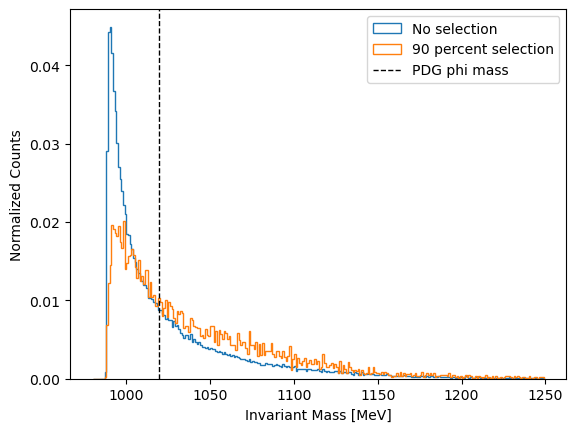

Epoch 2
-------------------------------
Classifier training loss: -13.811695
Adversary training loss: 2.312067
Classifier validation loss: -13.826364
Adversary validation loss: 2.315896
Diff score: 1.978914


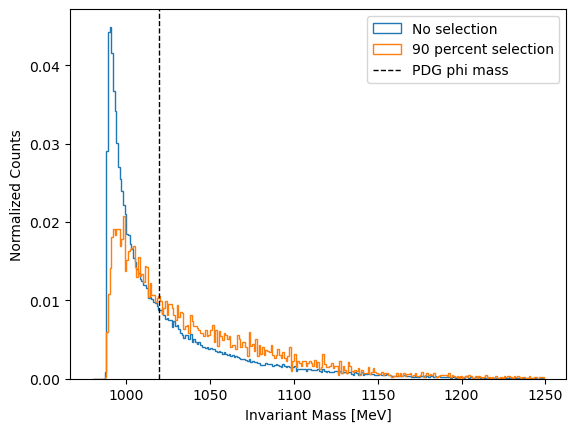

Epoch 3
-------------------------------
Classifier training loss: -13.802930
Adversary training loss: 2.310576
Classifier validation loss: -13.821259
Adversary validation loss: 2.314645
Diff score: 2.055961


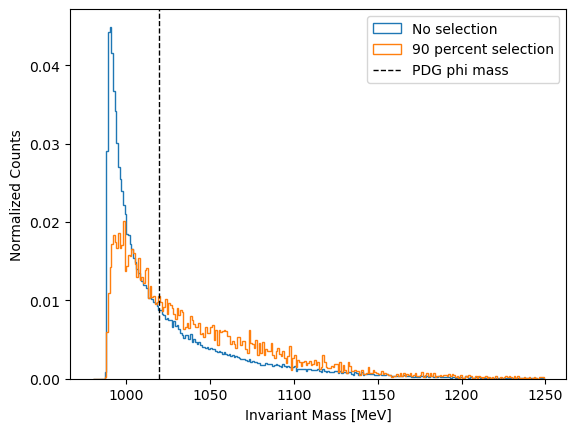

Epoch 4
-------------------------------
Classifier training loss: -13.793840
Adversary training loss: 2.309588
Classifier validation loss: -13.803283
Adversary validation loss: 2.312564
Diff score: 1.990869


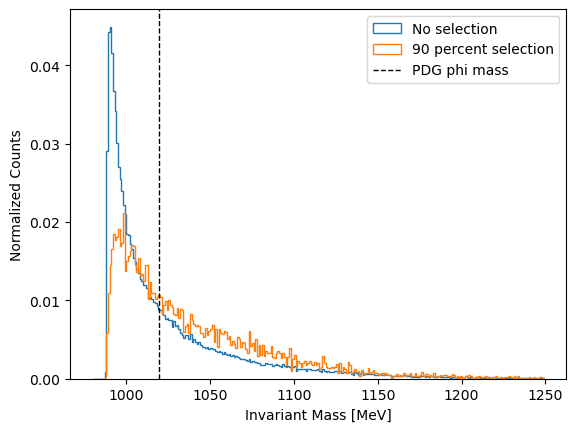

Epoch 5
-------------------------------
Classifier training loss: -13.791693
Adversary training loss: 2.308623
Classifier validation loss: -13.811804
Adversary validation loss: 2.313448
Diff score: 2.086242


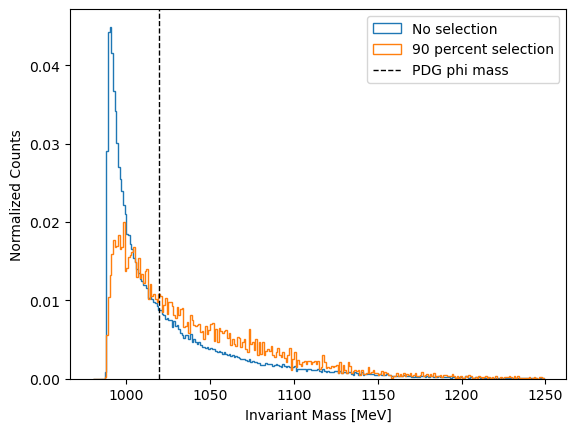

Epoch 6
-------------------------------
Classifier training loss: -13.789348
Adversary training loss: 2.307815
Classifier validation loss: -13.798372
Adversary validation loss: 2.310990
Diff score: 2.075614


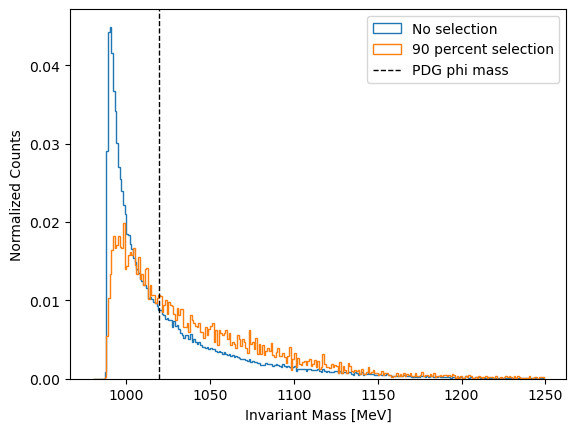

Epoch 7
-------------------------------
Classifier training loss: -13.780877
Adversary training loss: 2.307130
Classifier validation loss: -13.803196
Adversary validation loss: 2.311708
Diff score: 2.133855


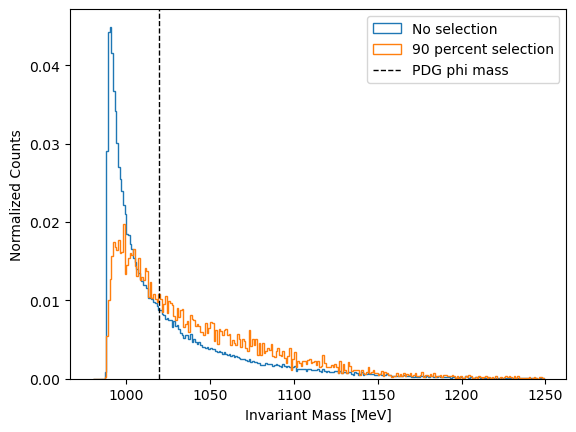

Epoch 8
-------------------------------
Classifier training loss: -13.773776
Adversary training loss: 2.306603
Classifier validation loss: -13.796551
Adversary validation loss: 2.311166
Diff score: 2.105867


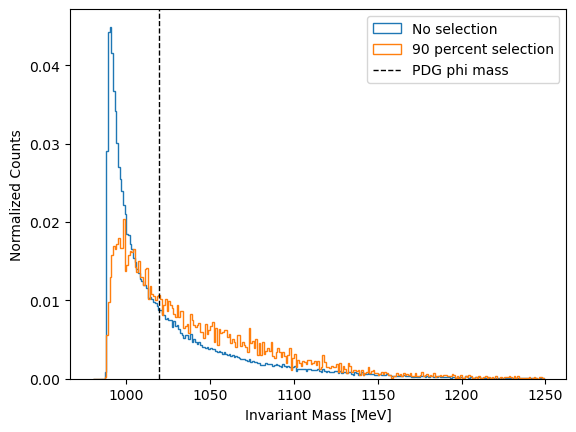

Epoch 9
-------------------------------
Classifier training loss: -13.773078
Adversary training loss: 2.306033
Classifier validation loss: -13.791170
Adversary validation loss: 2.310088
Diff score: 2.151730


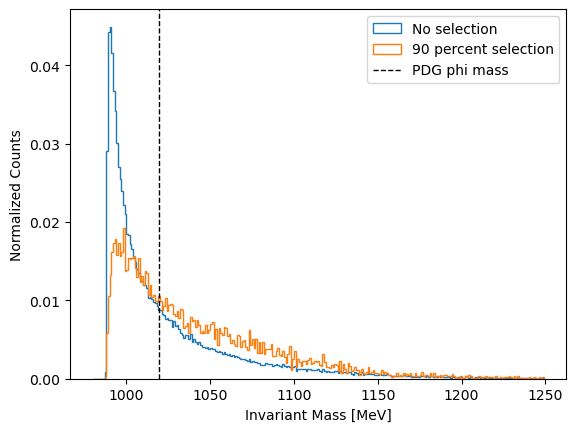

Epoch 10
-------------------------------
Classifier training loss: -13.772643
Adversary training loss: 2.305567
Classifier validation loss: -13.789774
Adversary validation loss: 2.309705
Diff score: 2.041752


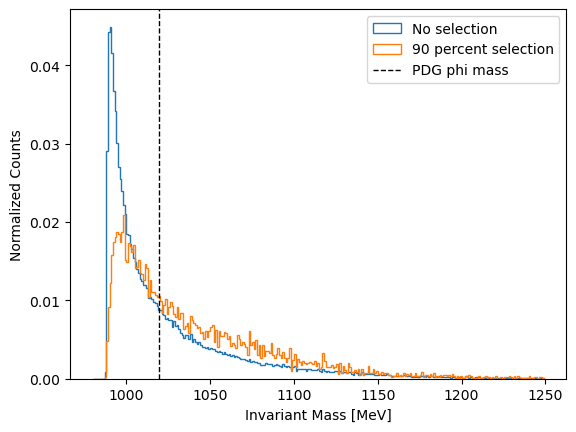

Epoch 11
-------------------------------
Classifier training loss: -13.770313
Adversary training loss: 2.305079
Classifier validation loss: -13.782213
Adversary validation loss: 2.308259
Diff score: 2.138032


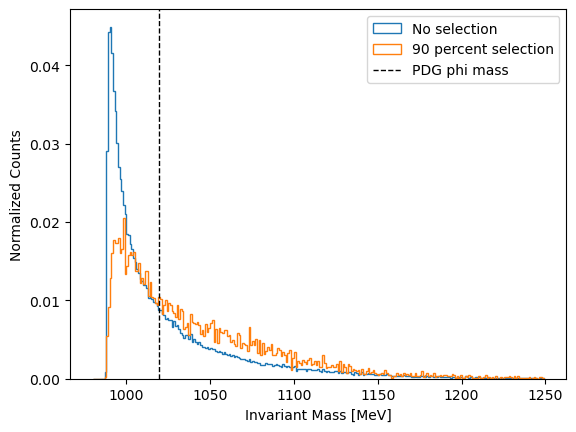

Epoch 12
-------------------------------
Classifier training loss: -13.767268
Adversary training loss: 2.304956
Classifier validation loss: -13.789288
Adversary validation loss: 2.309489
Diff score: 2.121746


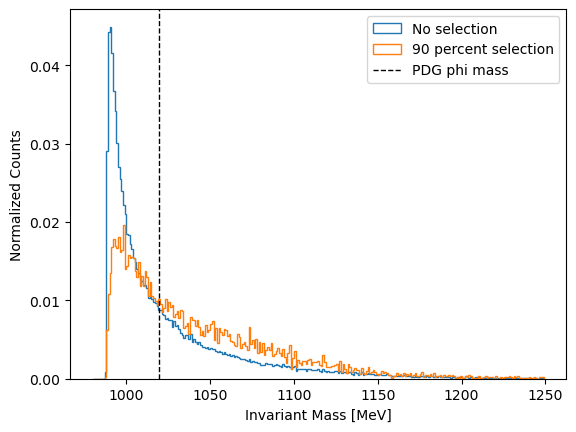

Epoch 13
-------------------------------
Classifier training loss: -13.766615
Adversary training loss: 2.304817
Classifier validation loss: -13.776523
Adversary validation loss: 2.307497
Diff score: 2.204884


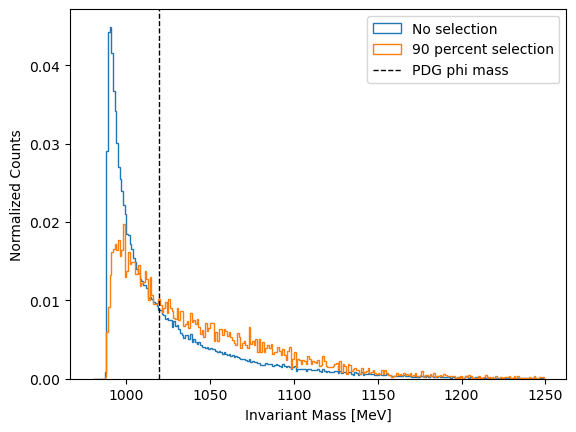

Epoch 14
-------------------------------
Classifier training loss: -13.766943
Adversary training loss: 2.304441
Classifier validation loss: -13.777726
Adversary validation loss: 2.308127
Diff score: 2.093940


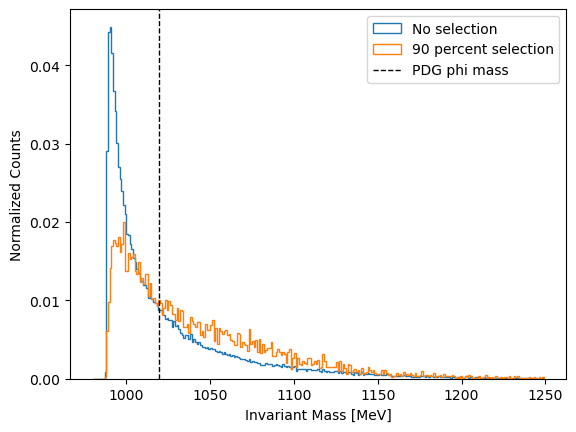

Epoch 15
-------------------------------
Classifier training loss: -13.766596
Adversary training loss: 2.304156
Classifier validation loss: -13.772966
Adversary validation loss: 2.307028
Diff score: 2.136537


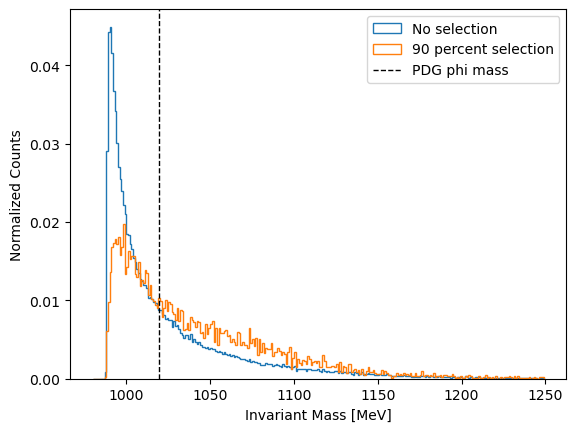

Epoch 16
-------------------------------
Classifier training loss: -13.760589
Adversary training loss: 2.304036
Classifier validation loss: -13.773109
Adversary validation loss: 2.306870
Diff score: 2.107705


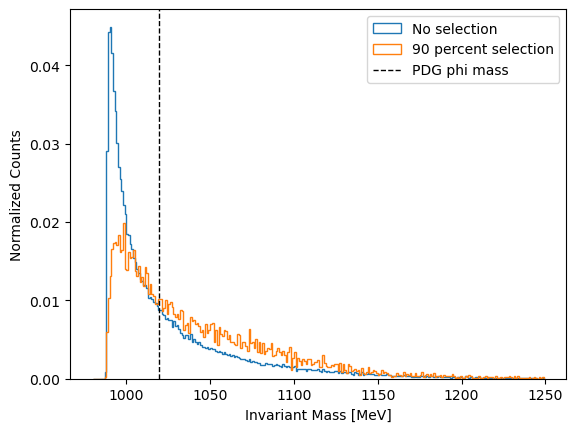

Epoch 17
-------------------------------
Classifier training loss: -13.764313
Adversary training loss: 2.303880
Classifier validation loss: -13.773909
Adversary validation loss: 2.307090
Diff score: 2.190230


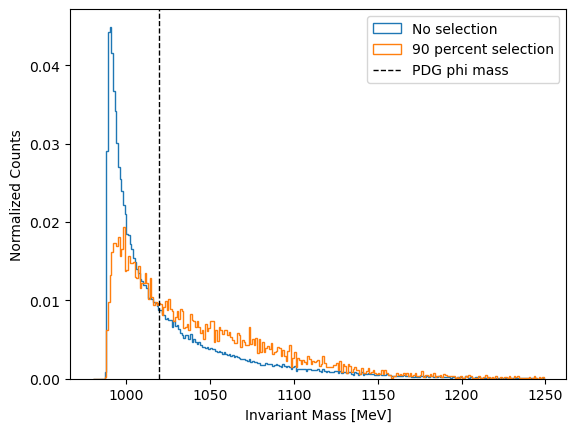

Epoch 18
-------------------------------
Classifier training loss: -13.761011
Adversary training loss: 2.303709
Classifier validation loss: -13.765788
Adversary validation loss: 2.306049
Diff score: 2.153258


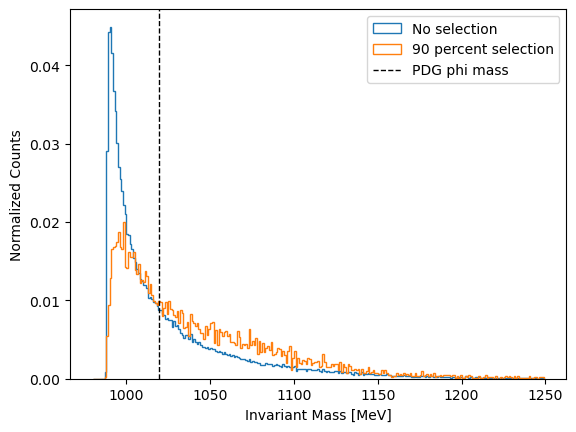

Epoch 19
-------------------------------
Classifier training loss: -13.763161
Adversary training loss: 2.303691
Classifier validation loss: -13.768617
Adversary validation loss: 2.306007
Diff score: 2.105649


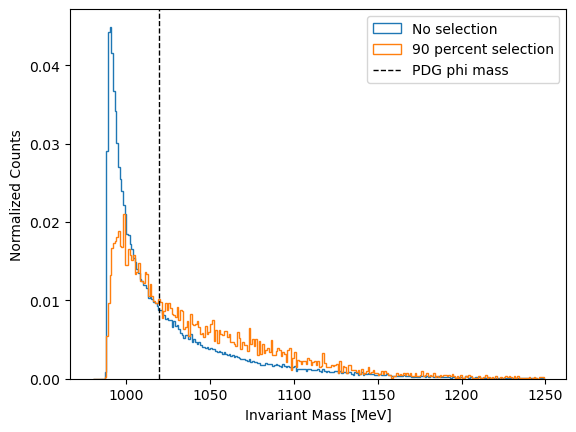

Epoch 20
-------------------------------
Classifier training loss: -13.762176
Adversary training loss: 2.303639
Classifier validation loss: -13.772542
Adversary validation loss: 2.306413
Diff score: 2.221473


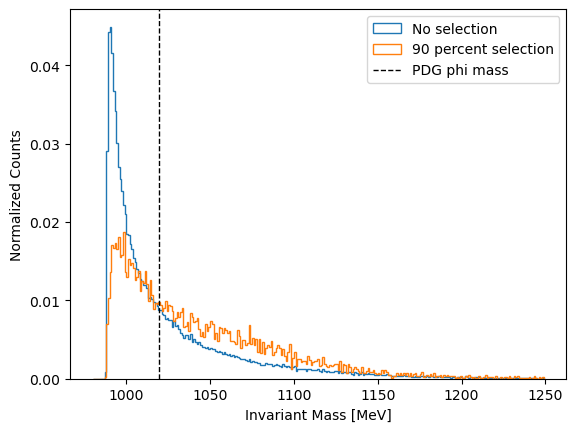

Epoch 21
-------------------------------
Classifier training loss: -13.759503
Adversary training loss: 2.303503
Classifier validation loss: -13.766762
Adversary validation loss: 2.305653
Diff score: 2.089213


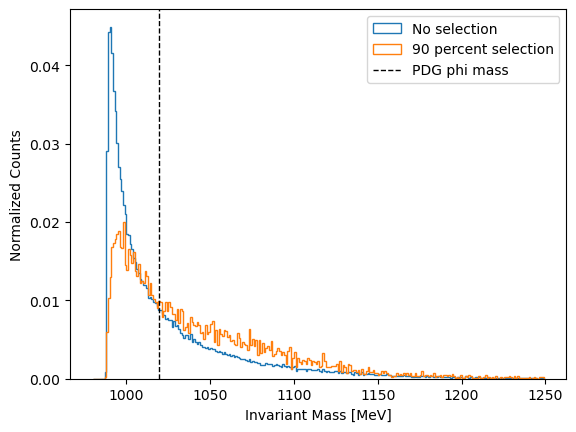

Epoch 22
-------------------------------
Classifier training loss: -13.758928
Adversary training loss: 2.303513
Classifier validation loss: -13.768881
Adversary validation loss: 2.306003
Diff score: 2.053383


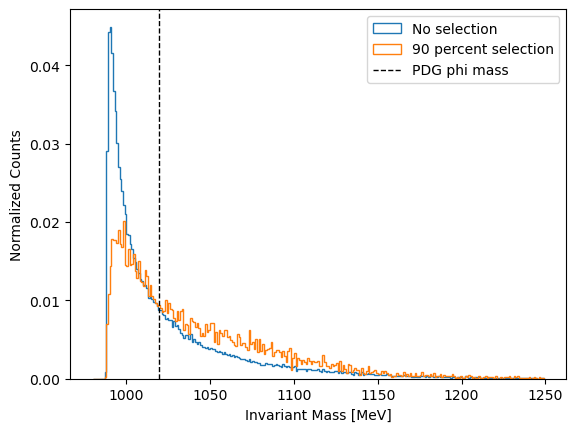

Epoch 23
-------------------------------
Classifier training loss: -13.758706
Adversary training loss: 2.303441
Classifier validation loss: -13.766766
Adversary validation loss: 2.305857
Diff score: 2.100110


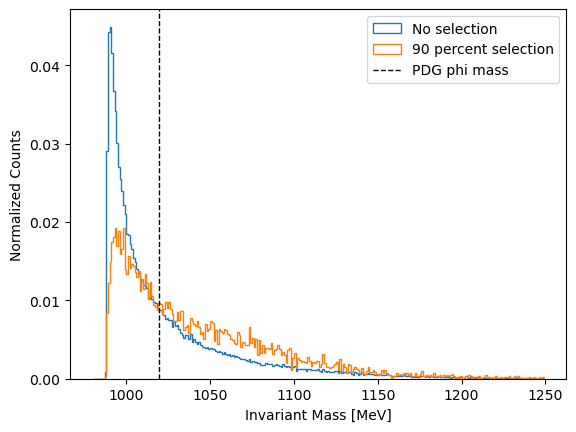

Epoch 24
-------------------------------
Classifier training loss: -13.758513
Adversary training loss: 2.303298
Classifier validation loss: -13.768279
Adversary validation loss: 2.305827
Diff score: 2.032762


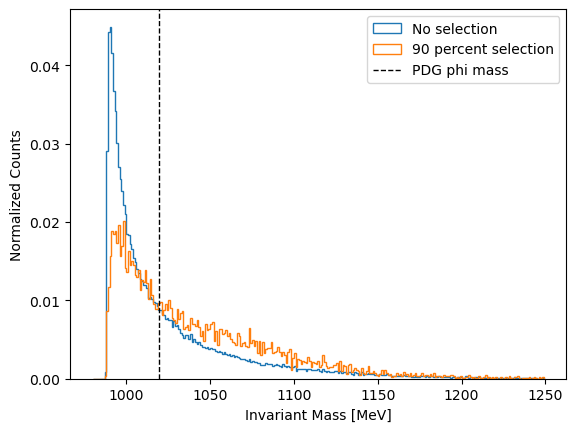

Epoch 25
-------------------------------
Classifier training loss: -13.761283
Adversary training loss: 2.303356
Classifier validation loss: -13.760055
Adversary validation loss: 2.305282
Diff score: 1.918092


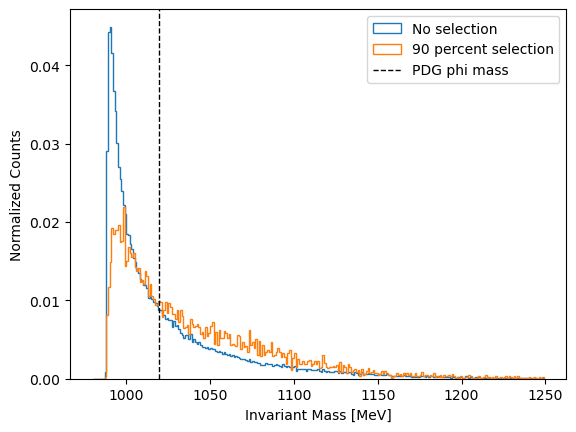

Epoch 26
-------------------------------
Classifier training loss: -13.759881
Adversary training loss: 2.303331
Classifier validation loss: -13.769532
Adversary validation loss: 2.305743
Diff score: 1.925170


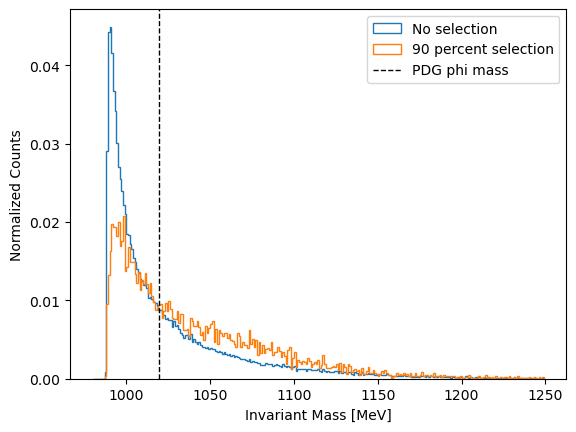

Epoch 27
-------------------------------
Classifier training loss: -13.757638
Adversary training loss: 2.303343
Classifier validation loss: -13.768870
Adversary validation loss: 2.306259
Diff score: 1.883063


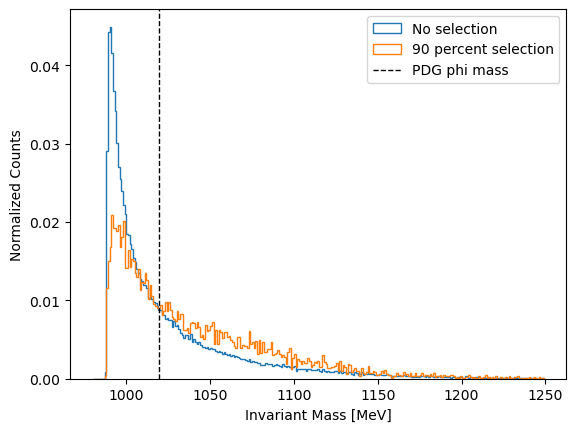

Epoch 28
-------------------------------
Classifier training loss: -13.758329
Adversary training loss: 2.303381
Classifier validation loss: -13.760609
Adversary validation loss: 2.304970
Diff score: 1.854771


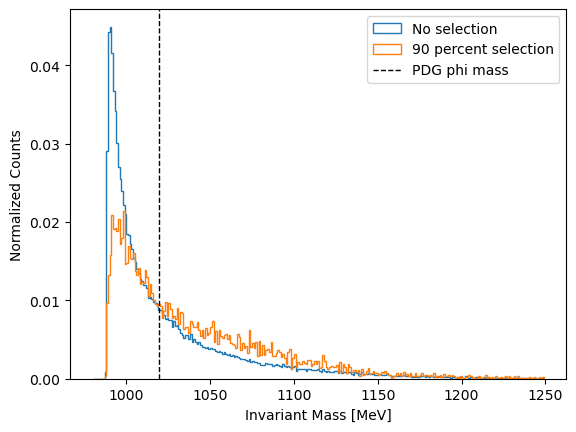

Epoch 29
-------------------------------
Classifier training loss: -13.757576
Adversary training loss: 2.303244
Classifier validation loss: -13.761757
Adversary validation loss: 2.305519
Diff score: 1.871197


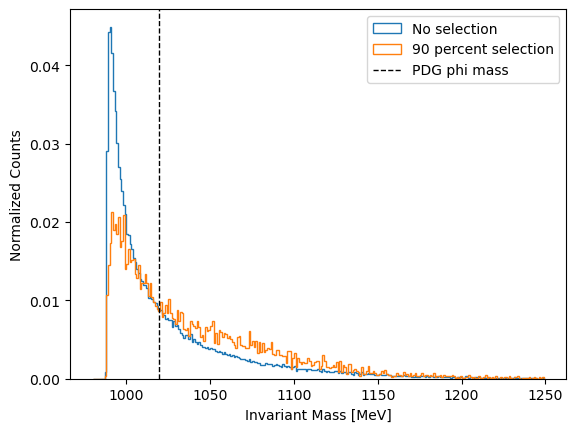

Epoch 30
-------------------------------
Classifier training loss: -13.761136
Adversary training loss: 2.303091
Classifier validation loss: -13.771132
Adversary validation loss: 2.306358
Diff score: 1.884723


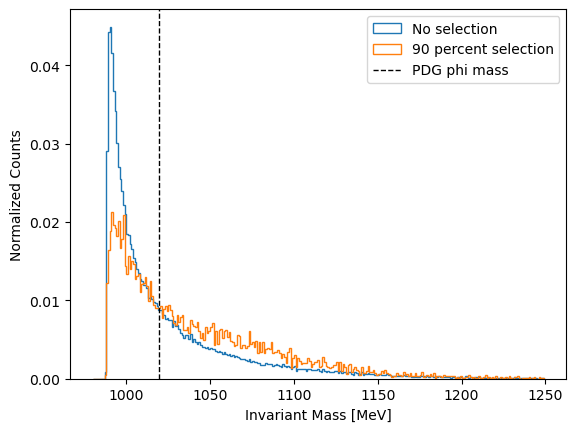

Epoch 31
-------------------------------
Classifier training loss: -13.756645
Adversary training loss: 2.303200
Classifier validation loss: -13.766887
Adversary validation loss: 2.305416
Diff score: 1.822196


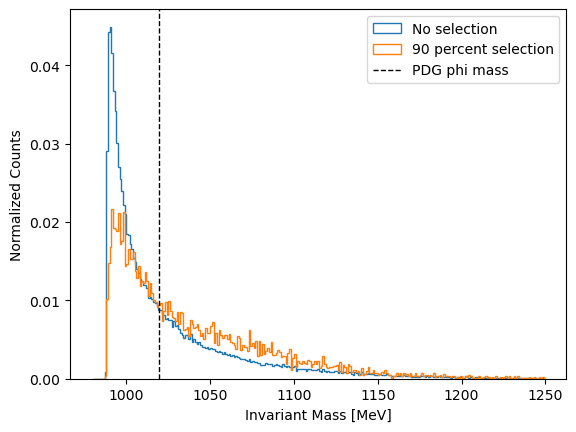

Epoch 32
-------------------------------
Classifier training loss: -13.755261
Adversary training loss: 2.303140
Classifier validation loss: -13.761746
Adversary validation loss: 2.305144
Diff score: 1.809806


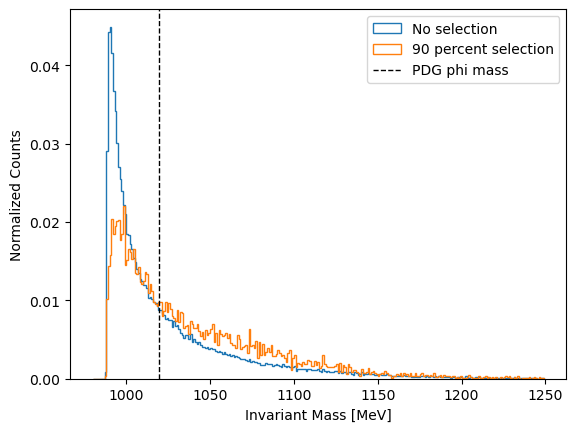

Epoch 33
-------------------------------
Classifier training loss: -13.755708
Adversary training loss: 2.303196
Classifier validation loss: -13.757613
Adversary validation loss: 2.304871
Diff score: 1.780195


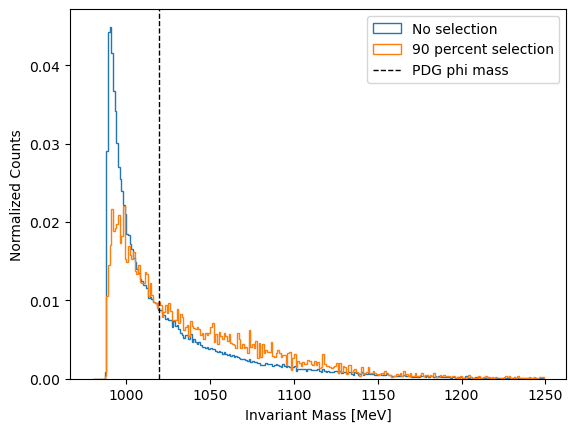

Epoch 34
-------------------------------
Classifier training loss: -13.756089
Adversary training loss: 2.303107
Classifier validation loss: -13.765902
Adversary validation loss: 2.305550
Diff score: 1.720880


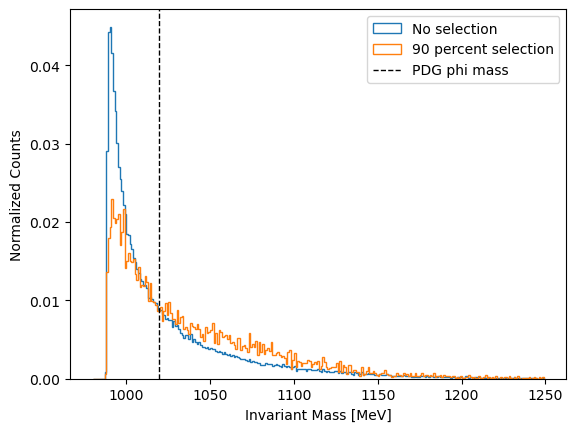

Epoch 35
-------------------------------
Classifier training loss: -13.760558
Adversary training loss: 2.303176
Classifier validation loss: -13.757803
Adversary validation loss: 2.304791
Diff score: 1.684944


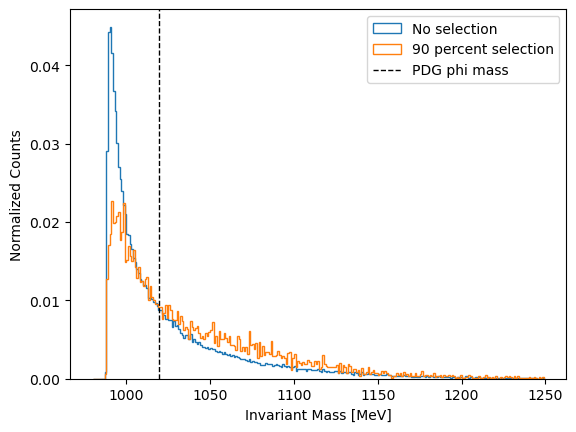

Epoch 36
-------------------------------
Classifier training loss: -13.758471
Adversary training loss: 2.303194
Classifier validation loss: -13.758958
Adversary validation loss: 2.304839
Diff score: 1.747466


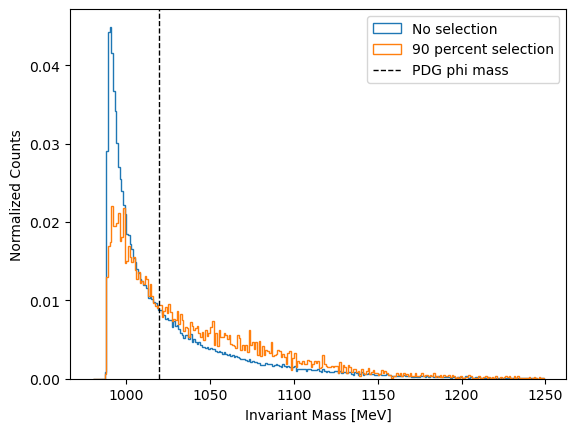

Epoch 37
-------------------------------
Classifier training loss: -13.758555
Adversary training loss: 2.303189
Classifier validation loss: -13.758363
Adversary validation loss: 2.304555
Diff score: 1.729026


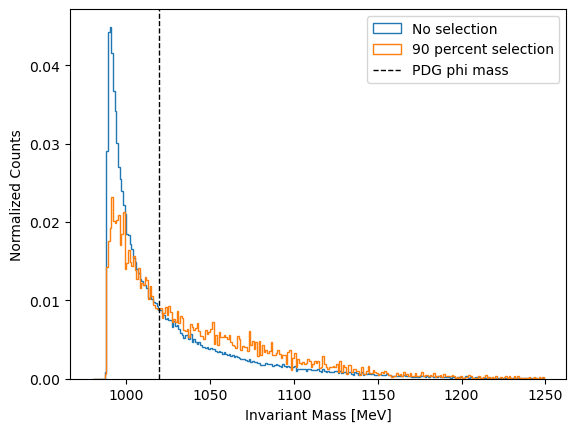

Epoch 38
-------------------------------
Classifier training loss: -13.759357
Adversary training loss: 2.303229
Classifier validation loss: -13.767030
Adversary validation loss: 2.305757
Diff score: 1.748976


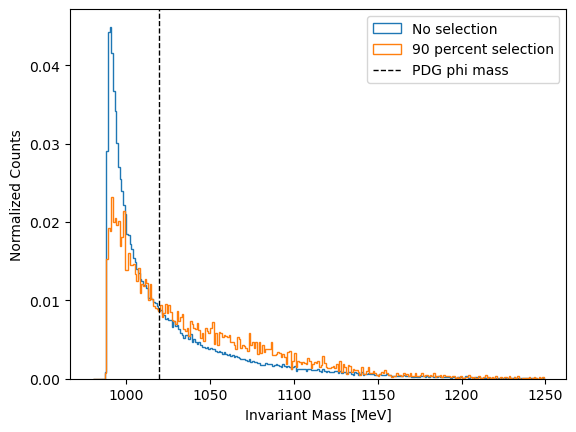

Epoch 39
-------------------------------
Classifier training loss: -13.757107
Adversary training loss: 2.303067
Classifier validation loss: -13.764136
Adversary validation loss: 2.305599
Diff score: 1.634786


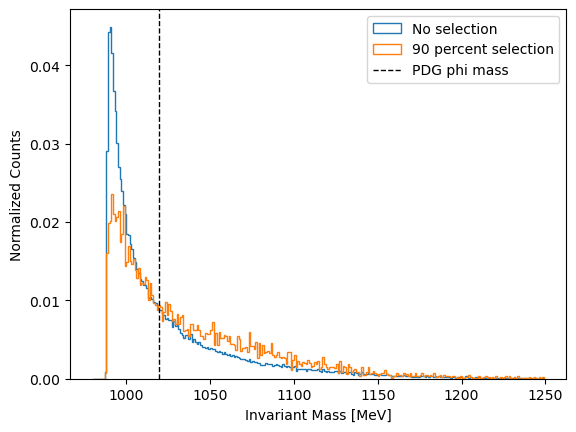

Epoch 40
-------------------------------
Classifier training loss: -13.750665
Adversary training loss: 2.303227
Classifier validation loss: -13.767248
Adversary validation loss: 2.305730
Diff score: 1.634557


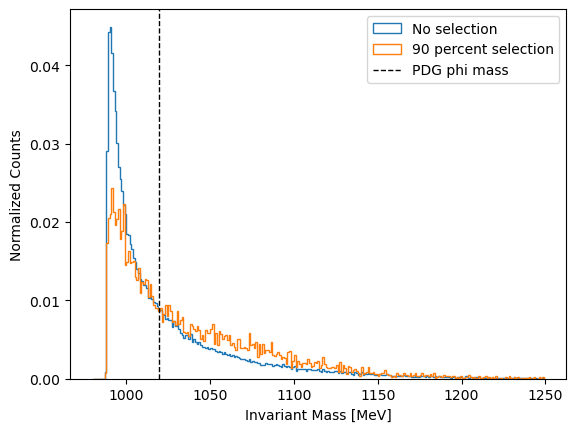

Epoch 41
-------------------------------
Classifier training loss: -13.754571
Adversary training loss: 2.303039
Classifier validation loss: -13.764013
Adversary validation loss: 2.305620
Diff score: 1.591752


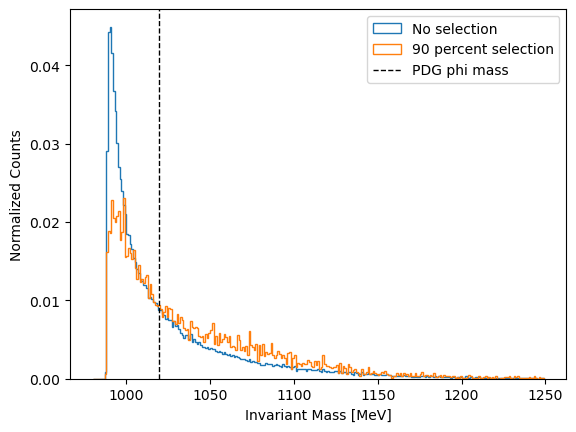

Epoch 42
-------------------------------
Classifier training loss: -13.753951
Adversary training loss: 2.303059
Classifier validation loss: -13.760452
Adversary validation loss: 2.305053
Diff score: 1.584210


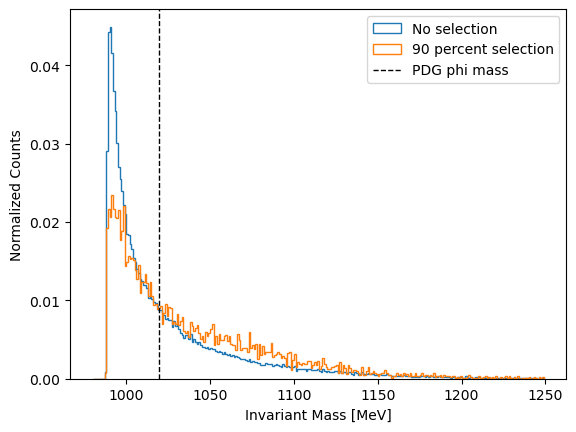

Epoch 43
-------------------------------
Classifier training loss: -13.758018
Adversary training loss: 2.303134
Classifier validation loss: -13.759585
Adversary validation loss: 2.304897
Diff score: 1.539171


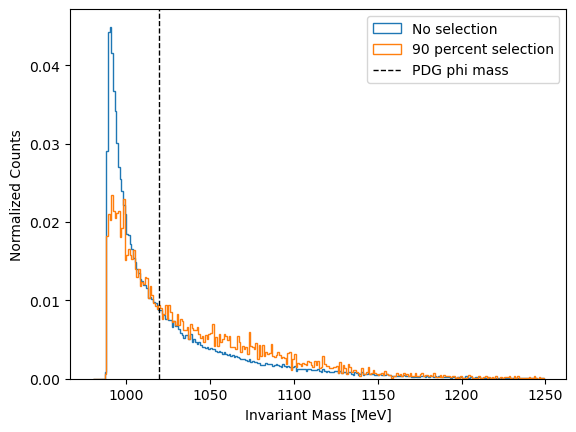

Epoch 44
-------------------------------
Classifier training loss: -13.747760
Adversary training loss: 2.303208
Classifier validation loss: -13.758880
Adversary validation loss: 2.304879
Diff score: 1.541804


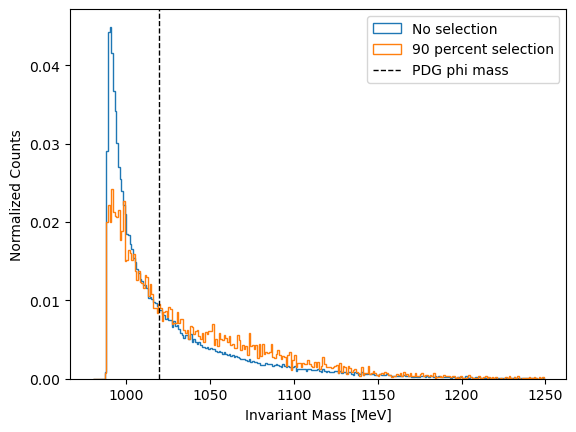

Epoch 45
-------------------------------
Classifier training loss: -13.754956
Adversary training loss: 2.303143
Classifier validation loss: -13.762607
Adversary validation loss: 2.305153
Diff score: 1.548437


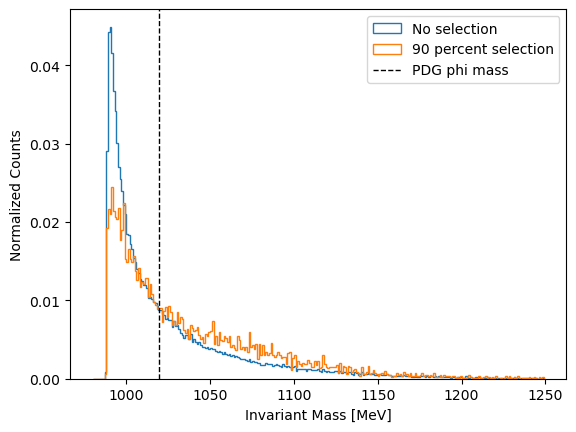

Epoch 46
-------------------------------
Classifier training loss: -13.757845
Adversary training loss: 2.303252
Classifier validation loss: -13.767482
Adversary validation loss: 2.305502
Diff score: 1.527526


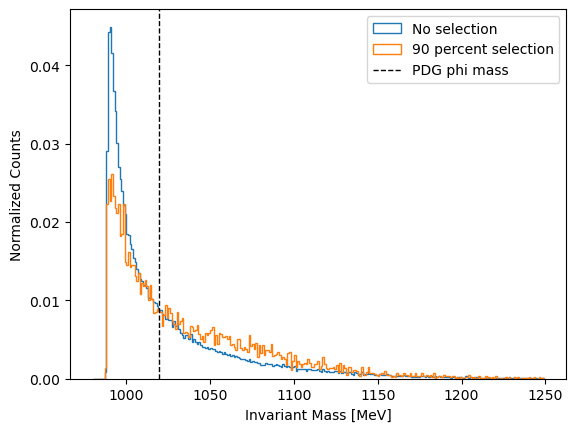

Epoch 47
-------------------------------
Classifier training loss: -13.753257
Adversary training loss: 2.303088
Classifier validation loss: -13.762476
Adversary validation loss: 2.305068
Diff score: 1.597191


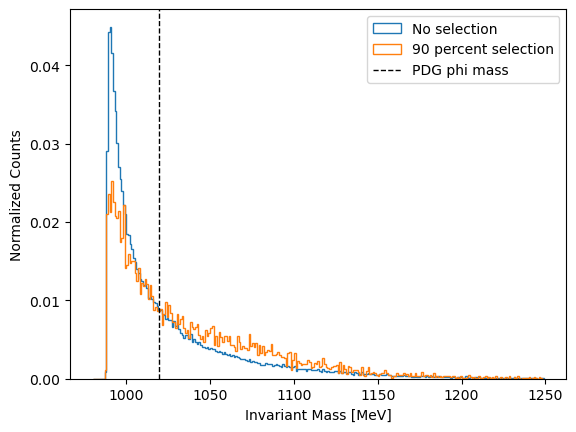

Epoch 48
-------------------------------
Classifier training loss: -13.756516
Adversary training loss: 2.303134
Classifier validation loss: -13.760038
Adversary validation loss: 2.304869
Diff score: 1.534251


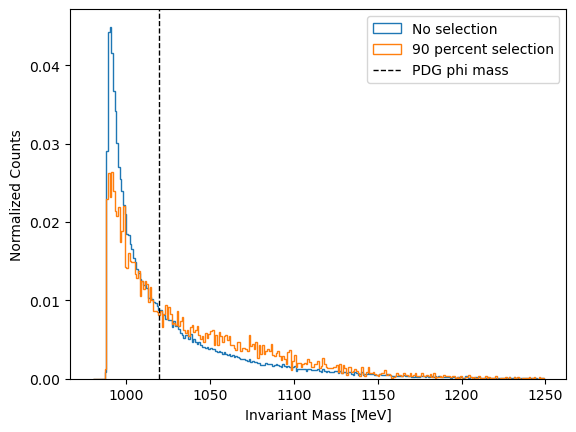

Epoch 49
-------------------------------
Classifier training loss: -13.756500
Adversary training loss: 2.303093
Classifier validation loss: -13.764914
Adversary validation loss: 2.305311
Diff score: 1.497557


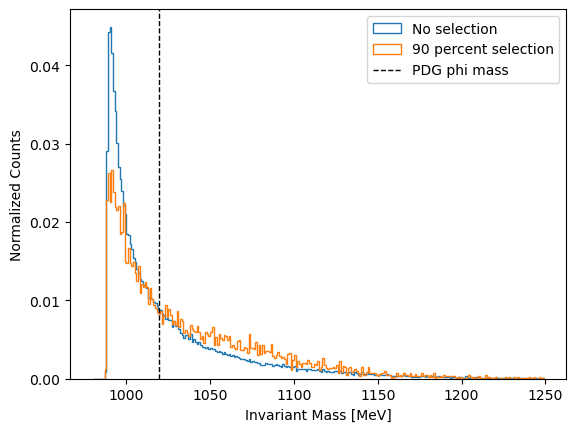

Epoch 50
-------------------------------
Classifier training loss: -13.755198
Adversary training loss: 2.303071
Classifier validation loss: -13.764727
Adversary validation loss: 2.305450
Diff score: 1.517350


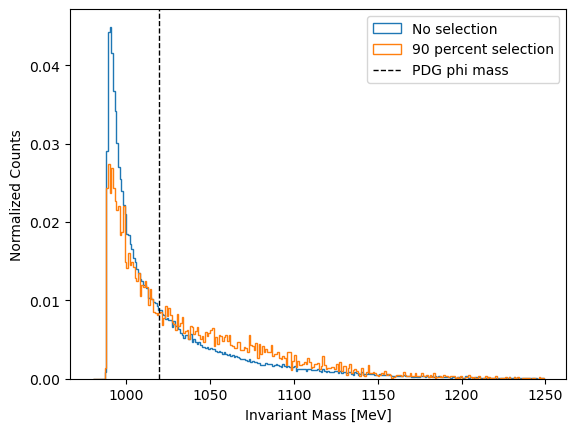

Epoch 51
-------------------------------
Classifier training loss: -13.754976
Adversary training loss: 2.303162
Classifier validation loss: -13.760804
Adversary validation loss: 2.305173
Diff score: 1.543093


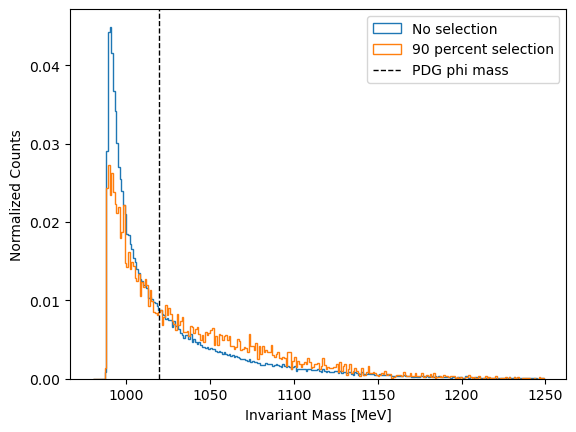

Epoch 52
-------------------------------
Classifier training loss: -13.756969
Adversary training loss: 2.303046
Classifier validation loss: -13.761016
Adversary validation loss: 2.304908
Diff score: 1.473694


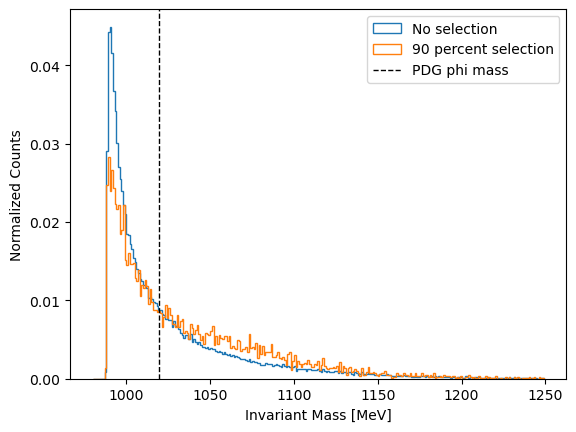

Epoch 53
-------------------------------
Classifier training loss: -13.754991
Adversary training loss: 2.303289
Classifier validation loss: -13.762776
Adversary validation loss: 2.305355
Diff score: 1.477642


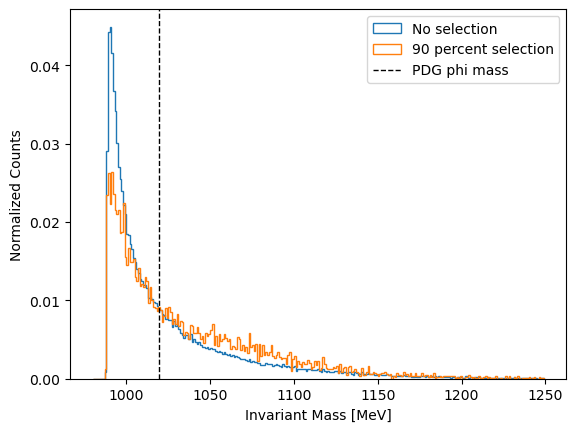

Epoch 54
-------------------------------
Classifier training loss: -13.757997
Adversary training loss: 2.302977
Classifier validation loss: -13.757662
Adversary validation loss: 2.304315
Diff score: 1.460976


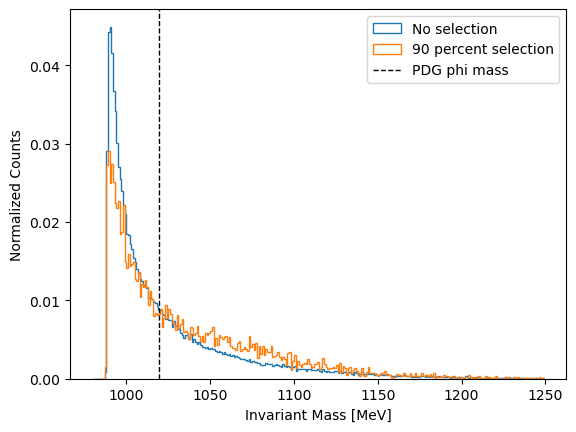

Epoch 55
-------------------------------
Classifier training loss: -13.755699
Adversary training loss: 2.303233
Classifier validation loss: -13.758643
Adversary validation loss: 2.305104
Diff score: 1.491085


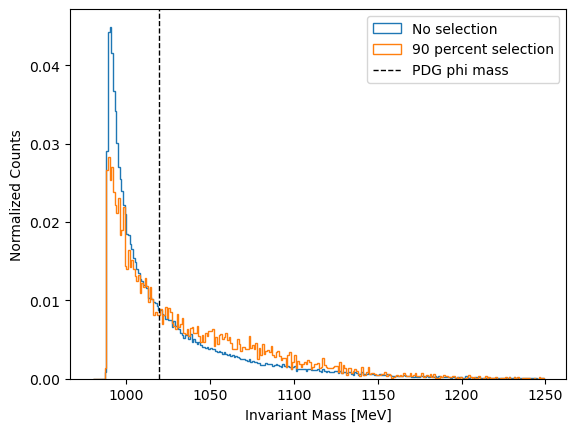

Epoch 56
-------------------------------
Classifier training loss: -13.754012
Adversary training loss: 2.303202
Classifier validation loss: -13.762107
Adversary validation loss: 2.304897
Diff score: 1.497033


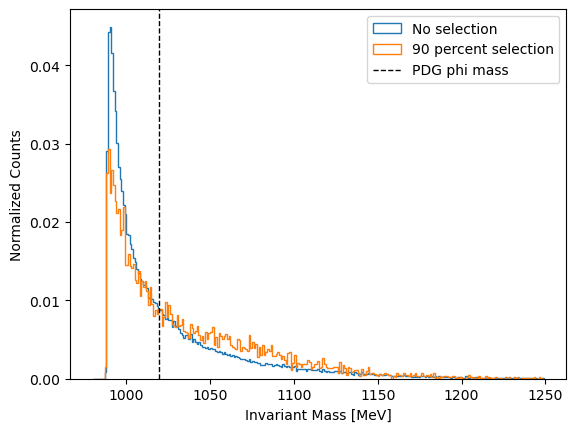

Epoch 57
-------------------------------
Classifier training loss: -13.756933
Adversary training loss: 2.303176
Classifier validation loss: -13.761411
Adversary validation loss: 2.305509
Diff score: 1.342236


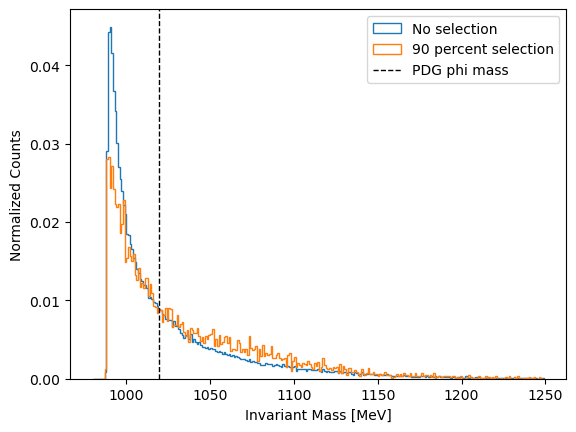

Epoch 58
-------------------------------
Classifier training loss: -13.757869
Adversary training loss: 2.302992
Classifier validation loss: -13.762836
Adversary validation loss: 2.305294
Diff score: 1.437733


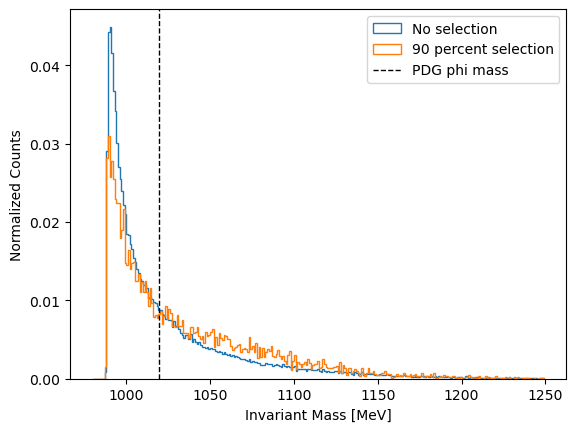

Epoch 59
-------------------------------
Classifier training loss: -13.756975
Adversary training loss: 2.303085
Classifier validation loss: -13.763584
Adversary validation loss: 2.305418
Diff score: 1.401027


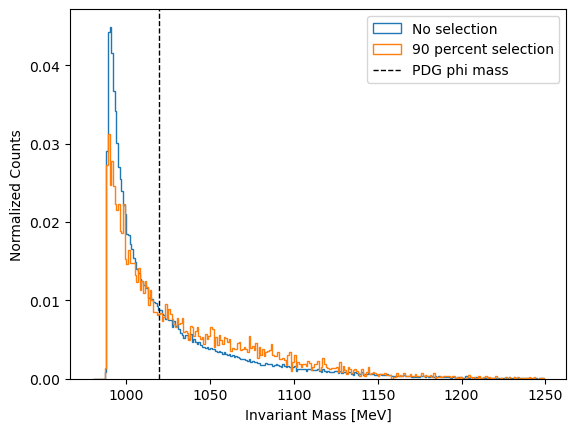

Epoch 60
-------------------------------
Classifier training loss: -13.756478
Adversary training loss: 2.303020
Classifier validation loss: -13.762419
Adversary validation loss: 2.305085
Diff score: 1.419034


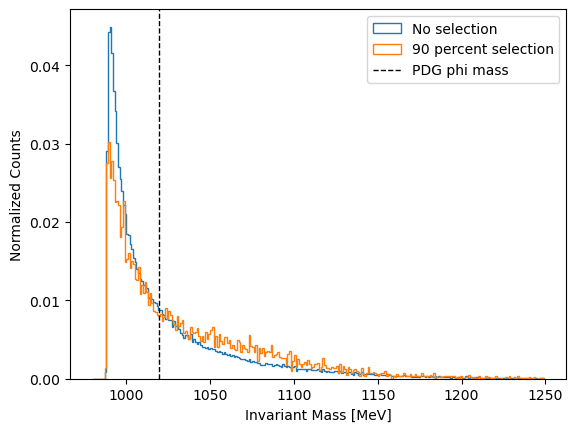

Epoch 61
-------------------------------
Classifier training loss: -13.755442
Adversary training loss: 2.303009
Classifier validation loss: -13.758984
Adversary validation loss: 2.304604
Diff score: 1.364258


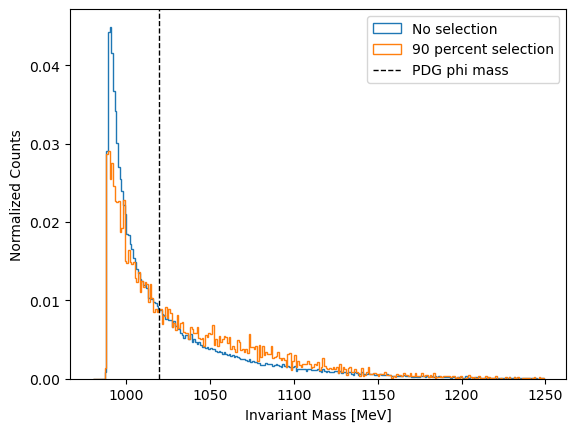

Epoch 62
-------------------------------
Classifier training loss: -13.756567
Adversary training loss: 2.303054
Classifier validation loss: -13.754344
Adversary validation loss: 2.304326
Diff score: 1.411158


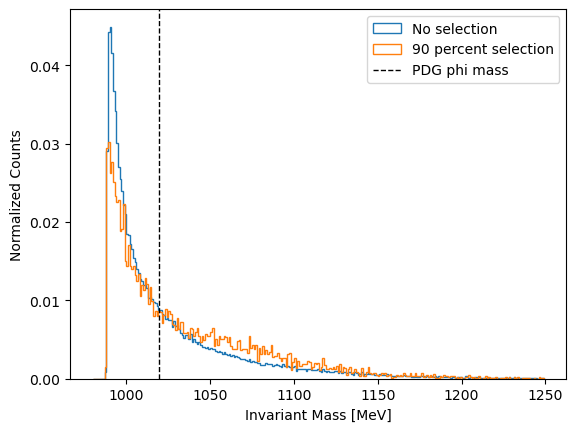

Epoch 63
-------------------------------
Classifier training loss: -13.756337
Adversary training loss: 2.303032
Classifier validation loss: -13.764254
Adversary validation loss: 2.305676
Diff score: 1.386789


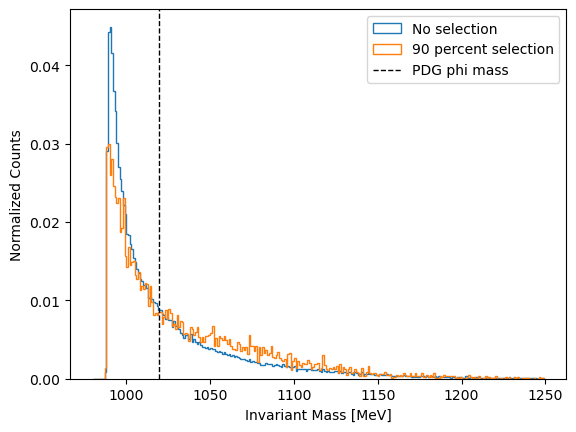

Epoch 64
-------------------------------
Classifier training loss: -13.755772
Adversary training loss: 2.303102
Classifier validation loss: -13.757464
Adversary validation loss: 2.304536
Diff score: 1.343762


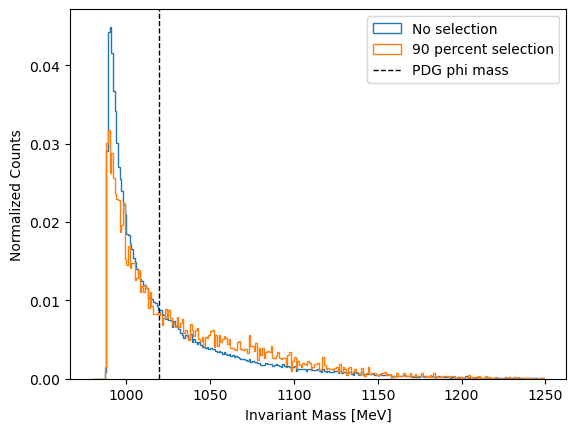

Epoch 65
-------------------------------
Classifier training loss: -13.753675
Adversary training loss: 2.303100
Classifier validation loss: -13.759558
Adversary validation loss: 2.304787
Diff score: 1.366042


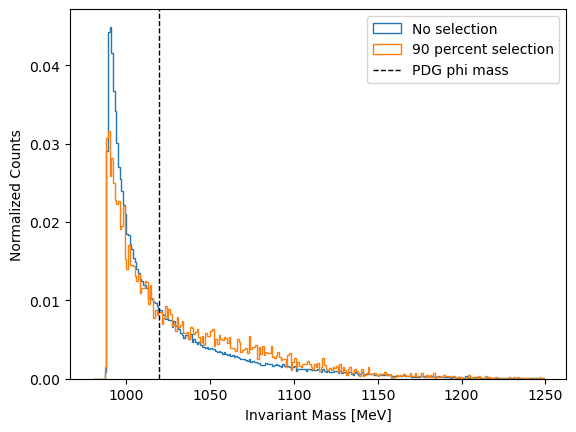

Epoch 66
-------------------------------
Classifier training loss: -13.756515
Adversary training loss: 2.303083
Classifier validation loss: -13.762083
Adversary validation loss: 2.304915
Diff score: 1.397863


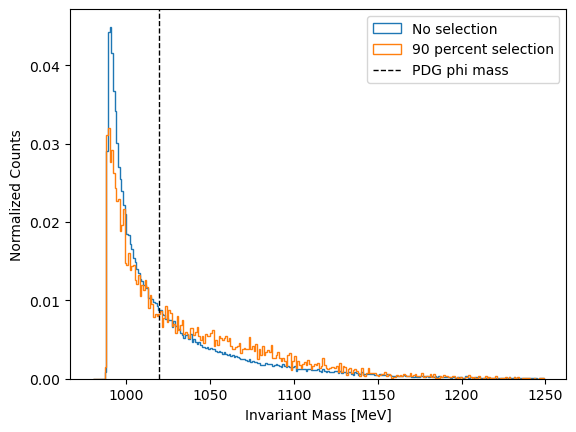

Epoch 67
-------------------------------
Classifier training loss: -13.757413
Adversary training loss: 2.303184
Classifier validation loss: -13.763019
Adversary validation loss: 2.305312
Diff score: 1.370103


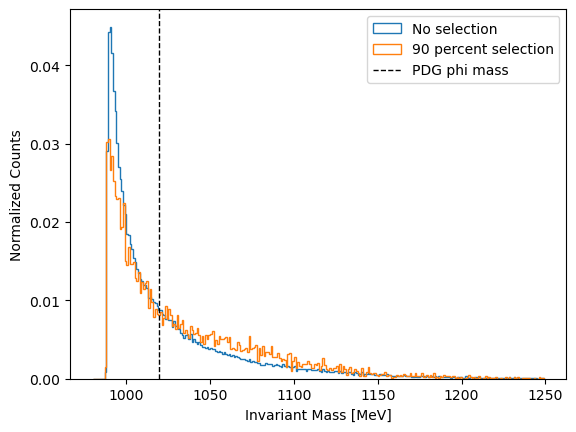

Epoch 68
-------------------------------
Classifier training loss: -13.751897
Adversary training loss: 2.303163
Classifier validation loss: -13.761357
Adversary validation loss: 2.304877
Diff score: 1.364012


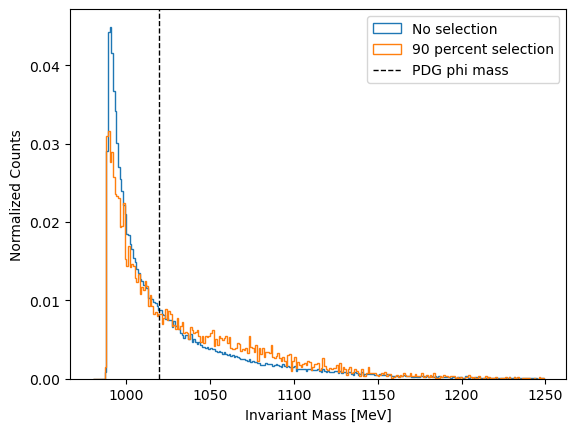

Epoch 69
-------------------------------
Classifier training loss: -13.758005
Adversary training loss: 2.303078
Classifier validation loss: -13.763833
Adversary validation loss: 2.305693
Diff score: 1.338431


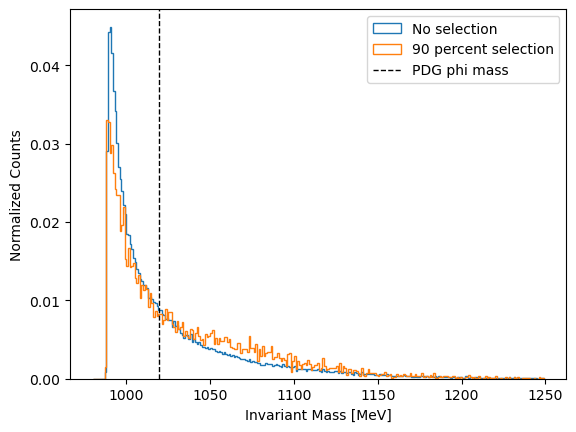

Epoch 70
-------------------------------
Classifier training loss: -13.755401
Adversary training loss: 2.303162
Classifier validation loss: -13.760872
Adversary validation loss: 2.305117
Diff score: 1.357150


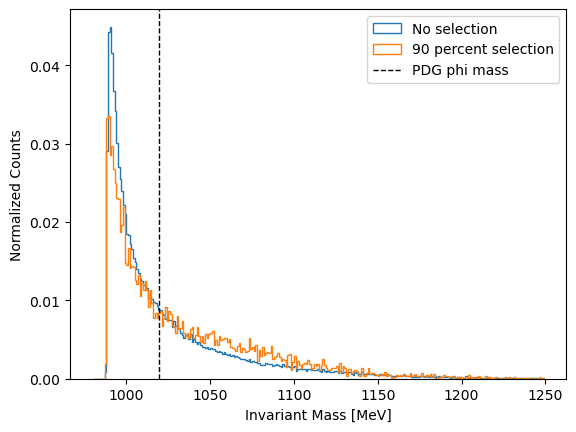

Epoch 71
-------------------------------
Classifier training loss: -13.754947
Adversary training loss: 2.303066
Classifier validation loss: -13.761422
Adversary validation loss: 2.305117
Diff score: 1.273753


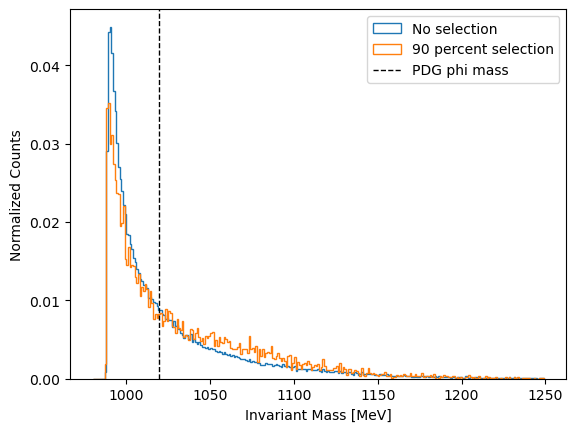

Epoch 72
-------------------------------
Classifier training loss: -13.756217
Adversary training loss: 2.302980
Classifier validation loss: -13.761448
Adversary validation loss: 2.305345
Diff score: 1.276455


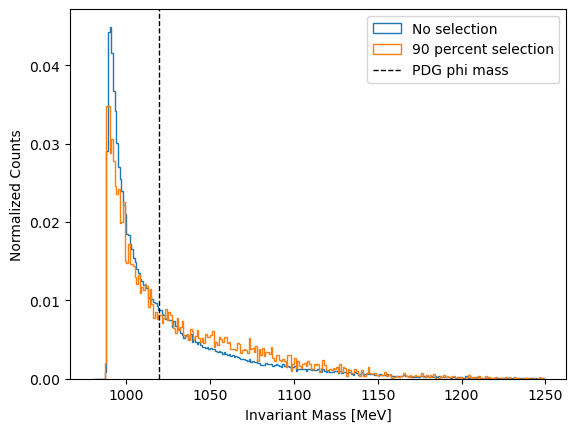

Epoch 73
-------------------------------
Classifier training loss: -13.753352
Adversary training loss: 2.303110
Classifier validation loss: -13.758854
Adversary validation loss: 2.304680
Diff score: 1.282966


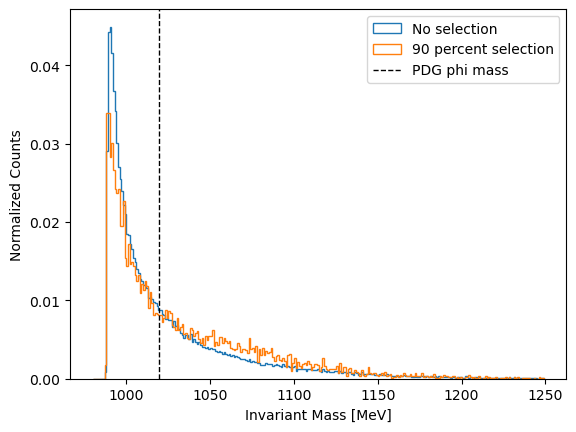

Epoch 74
-------------------------------
Classifier training loss: -13.757235
Adversary training loss: 2.303084
Classifier validation loss: -13.762322
Adversary validation loss: 2.305164
Diff score: 1.225820


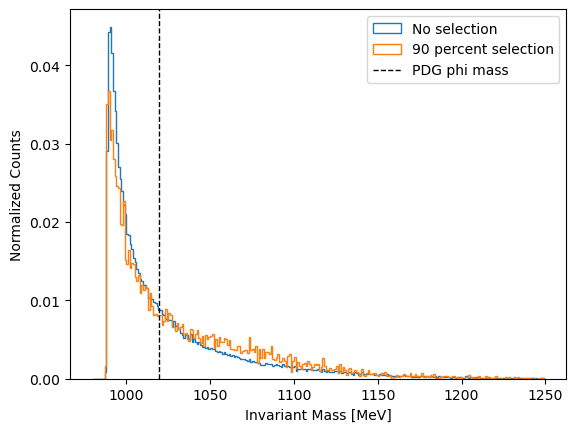

Epoch 75
-------------------------------
Classifier training loss: -13.753641
Adversary training loss: 2.303117
Classifier validation loss: -13.768331
Adversary validation loss: 2.306142
Diff score: 1.304025


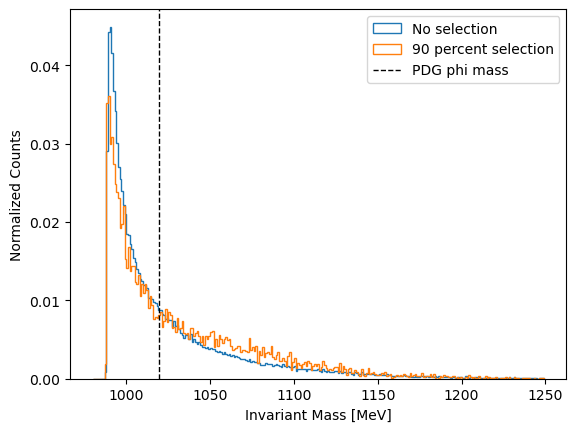

Epoch 76
-------------------------------
Classifier training loss: -13.755212
Adversary training loss: 2.303041
Classifier validation loss: -13.758191
Adversary validation loss: 2.304641
Diff score: 1.174512


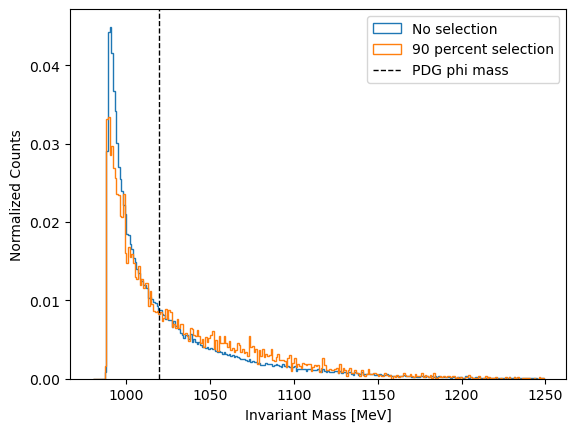

Epoch 77
-------------------------------
Classifier training loss: -13.748516
Adversary training loss: 2.303191
Classifier validation loss: -13.761551
Adversary validation loss: 2.304927
Diff score: 1.199980


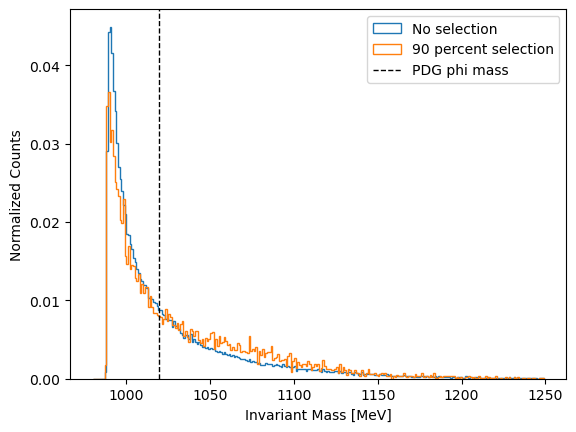

Epoch 78
-------------------------------
Classifier training loss: -13.754217
Adversary training loss: 2.303148
Classifier validation loss: -13.767299
Adversary validation loss: 2.305634
Diff score: 1.212001


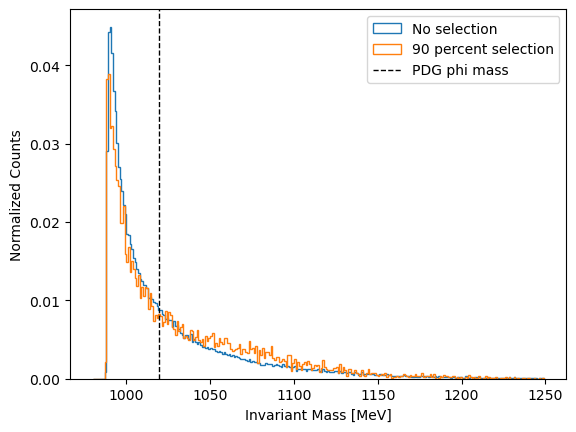

Epoch 79
-------------------------------
Classifier training loss: -13.757082
Adversary training loss: 2.303182
Classifier validation loss: -13.760264
Adversary validation loss: 2.304952
Diff score: 1.177253


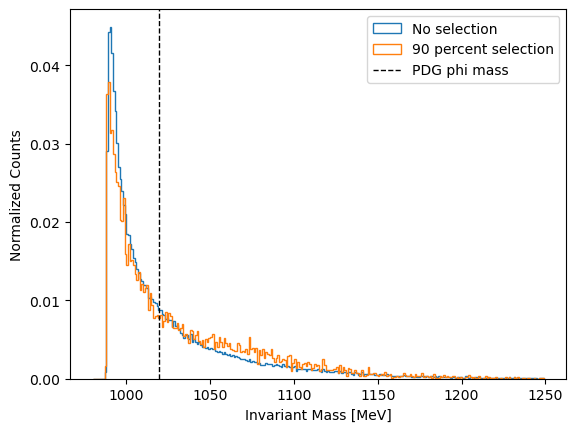

Epoch 80
-------------------------------
Classifier training loss: -13.757025
Adversary training loss: 2.303068
Classifier validation loss: -13.757736
Adversary validation loss: 2.304510
Diff score: 1.081300


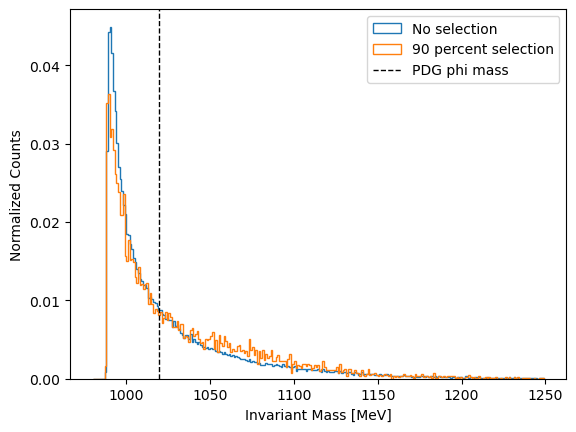

Epoch 81
-------------------------------
Classifier training loss: -13.756745
Adversary training loss: 2.303204
Classifier validation loss: -13.764062
Adversary validation loss: 2.305531
Diff score: 1.179368


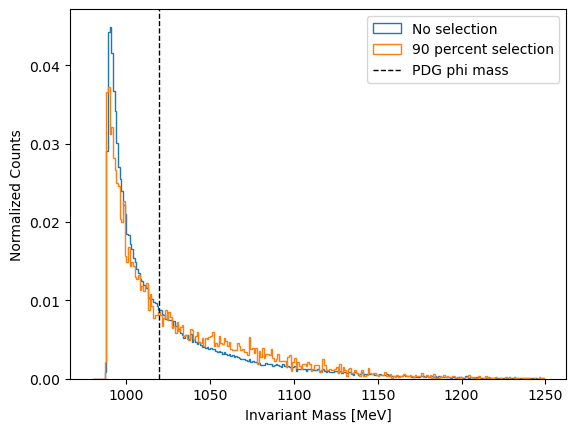

Epoch 82
-------------------------------
Classifier training loss: -13.754153
Adversary training loss: 2.303100
Classifier validation loss: -13.761269
Adversary validation loss: 2.305136
Diff score: 1.133906


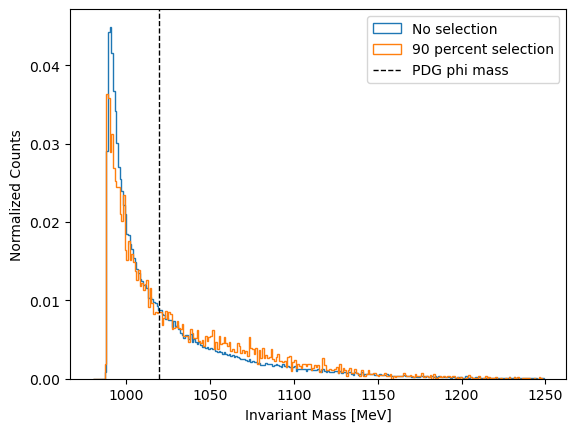

Epoch 83
-------------------------------
Classifier training loss: -13.754855
Adversary training loss: 2.303060
Classifier validation loss: -13.763405
Adversary validation loss: 2.305165
Diff score: 1.202230


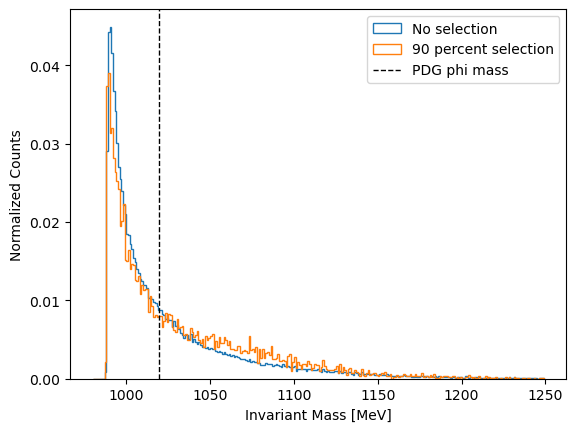

Epoch 84
-------------------------------
Classifier training loss: -13.755498
Adversary training loss: 2.303071
Classifier validation loss: -13.753038
Adversary validation loss: 2.303847
Diff score: 1.203128


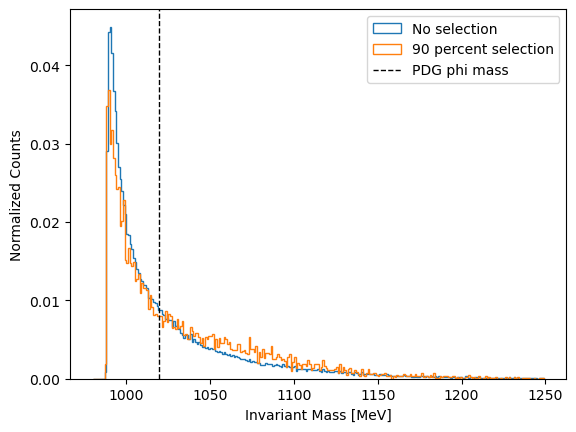

Epoch 85
-------------------------------
Classifier training loss: -13.754020
Adversary training loss: 2.303085
Classifier validation loss: -13.756725
Adversary validation loss: 2.304814
Diff score: 1.170354


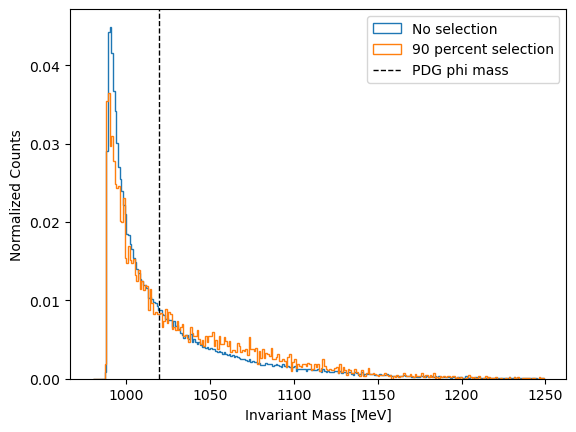

Epoch 86
-------------------------------
Classifier training loss: -13.753865
Adversary training loss: 2.303138
Classifier validation loss: -13.761812
Adversary validation loss: 2.305067
Diff score: 1.238564


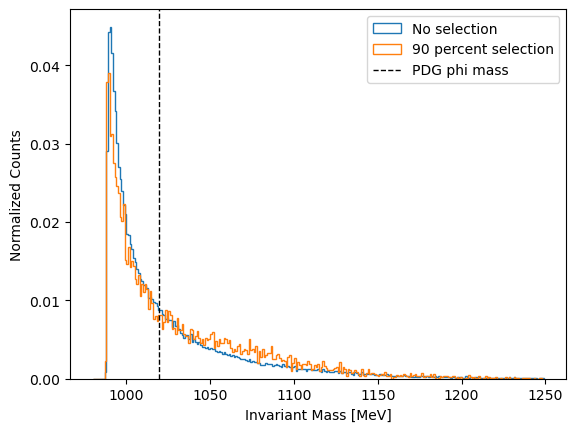

Epoch 87
-------------------------------
Classifier training loss: -13.756262
Adversary training loss: 2.302951
Classifier validation loss: -13.757875
Adversary validation loss: 2.304823
Diff score: 1.270383


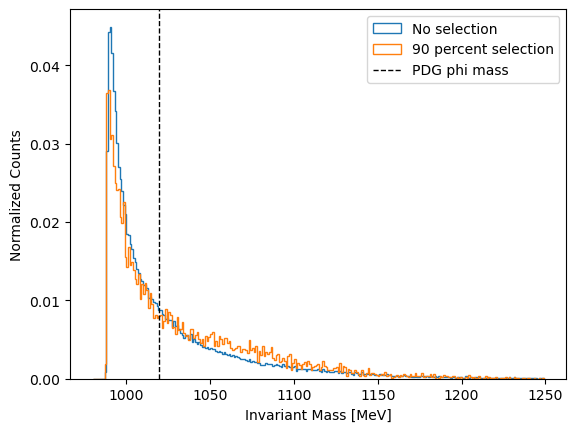

Epoch 88
-------------------------------
Classifier training loss: -13.750674
Adversary training loss: 2.302949
Classifier validation loss: -13.760523
Adversary validation loss: 2.304930
Diff score: 1.197060


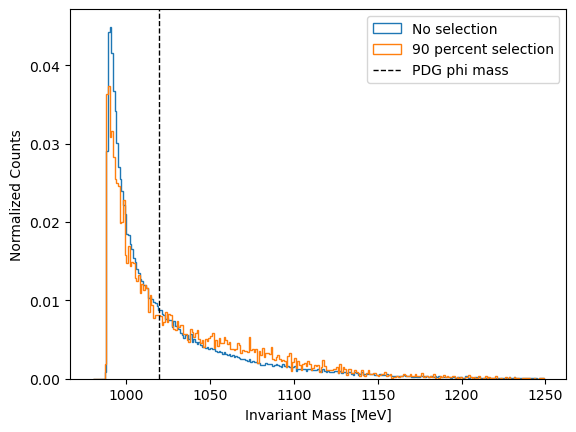

Epoch 89
-------------------------------
Classifier training loss: -13.755060
Adversary training loss: 2.303068
Classifier validation loss: -13.761180
Adversary validation loss: 2.305012
Diff score: 1.139927


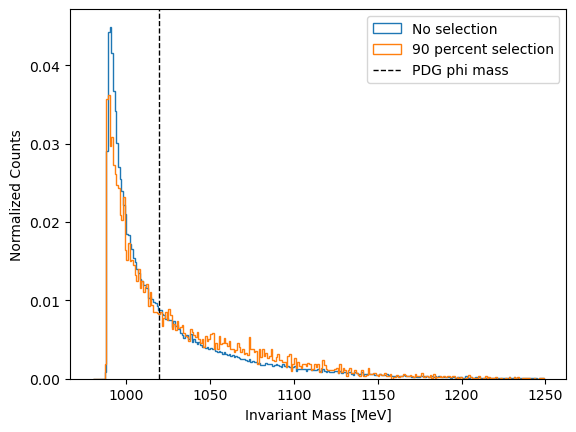

Epoch 90
-------------------------------
Classifier training loss: -13.753633
Adversary training loss: 2.303062
Classifier validation loss: -13.760065
Adversary validation loss: 2.304878
Diff score: 1.150030


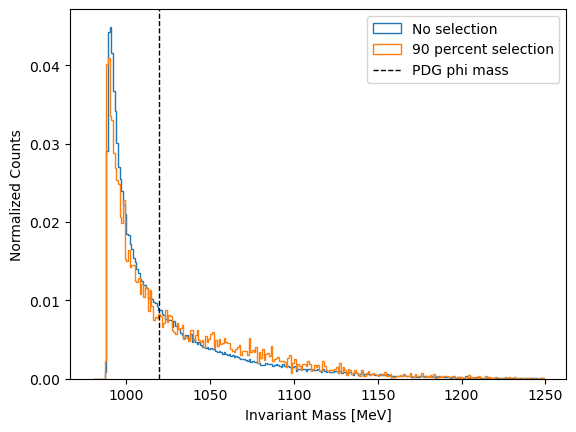

Epoch 91
-------------------------------
Classifier training loss: -13.754215
Adversary training loss: 2.303035
Classifier validation loss: -13.762602
Adversary validation loss: 2.305263
Diff score: 1.173800


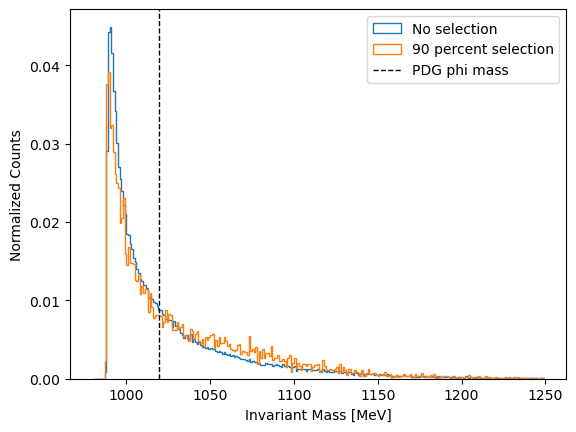

Epoch 92
-------------------------------
Classifier training loss: -13.756134
Adversary training loss: 2.303014
Classifier validation loss: -13.760473
Adversary validation loss: 2.305067
Diff score: 1.198521


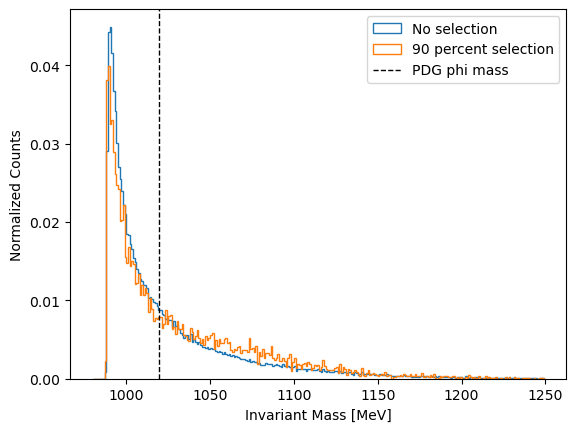

Epoch 93
-------------------------------
Classifier training loss: -13.757650
Adversary training loss: 2.303014
Classifier validation loss: -13.757428
Adversary validation loss: 2.304920
Diff score: 1.062069


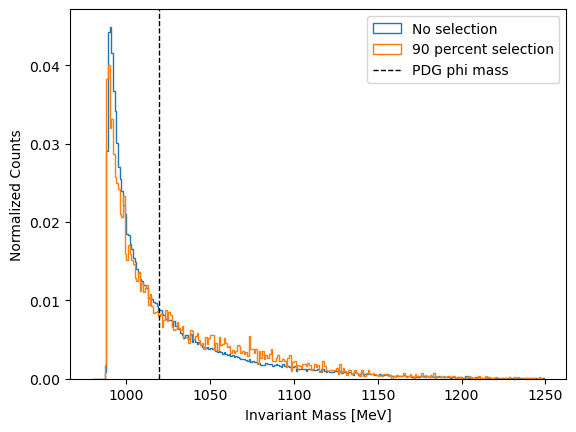

Epoch 94
-------------------------------
Classifier training loss: -13.754592
Adversary training loss: 2.302962
Classifier validation loss: -13.761926
Adversary validation loss: 2.305283
Diff score: 1.154235


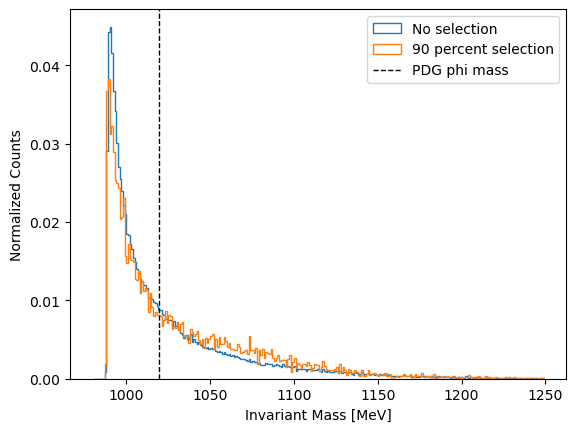

Epoch 95
-------------------------------
Classifier training loss: -13.755506
Adversary training loss: 2.303126
Classifier validation loss: -13.759284
Adversary validation loss: 2.305020
Diff score: 1.113919


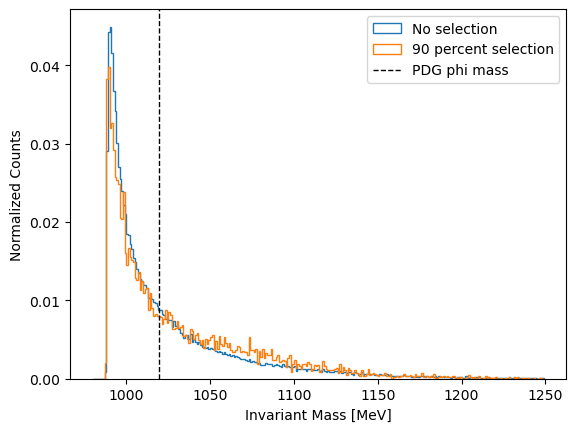

Epoch 96
-------------------------------
Classifier training loss: -13.753668
Adversary training loss: 2.302871
Classifier validation loss: -13.753381
Adversary validation loss: 2.304338
Diff score: 1.163043


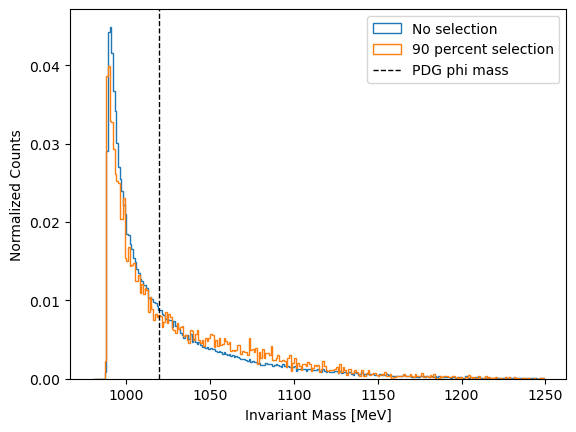

Epoch 97
-------------------------------
Classifier training loss: -13.754493
Adversary training loss: 2.303094
Classifier validation loss: -13.765448
Adversary validation loss: 2.305926
Diff score: 1.096706


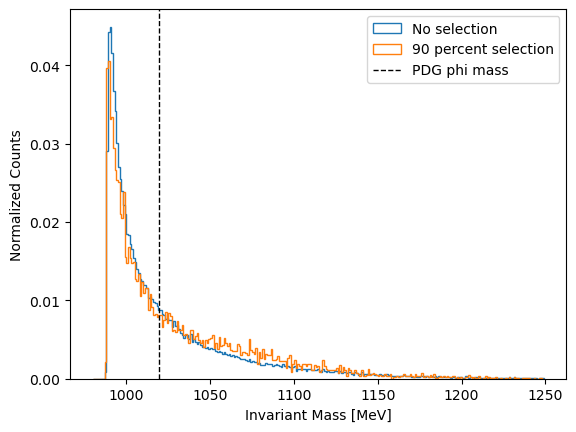

Epoch 98
-------------------------------
Classifier training loss: -13.753716
Adversary training loss: 2.303167
Classifier validation loss: -13.762378
Adversary validation loss: 2.305258
Diff score: 1.119565


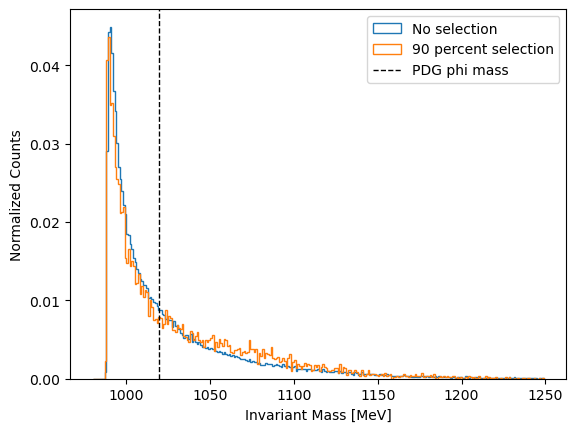

Epoch 99
-------------------------------
Classifier training loss: -13.753736
Adversary training loss: 2.303059
Classifier validation loss: -13.762781
Adversary validation loss: 2.305657
Diff score: 1.122040


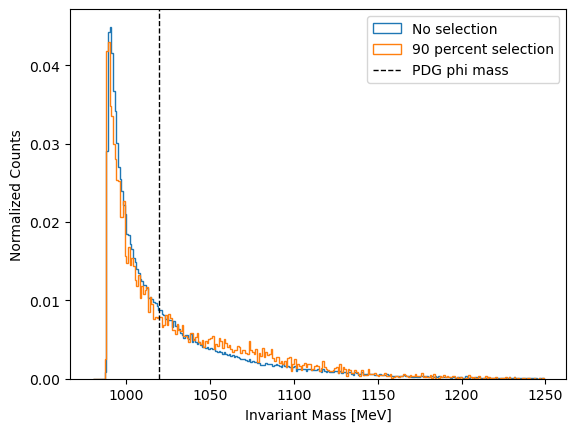

Epoch 100
-------------------------------
Classifier training loss: -13.755762
Adversary training loss: 2.303062
Classifier validation loss: -13.762683
Adversary validation loss: 2.305372
Diff score: 1.055556


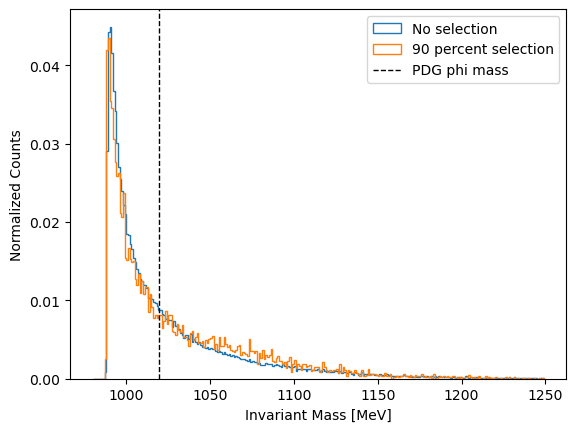

Done!


In [471]:


Training_losses_clas = np.array([])
Training_losses_adv = np.array([])
Validation_losses_clas = np.array([])
Validation_losses_adv = np.array([])
diff_scores = np.array([])


epochs = 100
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    
    # Train adversary and classifier
    E_clas_training_loss , E_adv_training_loss = mytools.train_full_orig(train_full_loader, final_classifier, final_adv, full_loss, lambda_, criterion_adv, optimizer_clas, optimizer_adv, scheduler_clas, scheduler_adv, 8, device, grad_clip = False)
    Training_losses_clas = np.append(Training_losses_clas, E_clas_training_loss)
    Training_losses_adv = np.append(Training_losses_adv, E_adv_training_loss)

    # Get validation losses
    E_clas_val_loss, E_adv_val_loss = mytools.validate_full(val_full_loader, final_classifier, final_adv, full_loss, lambda_, criterion_adv, device)
    Validation_losses_clas = np.append(Validation_losses_clas, E_clas_val_loss)
    Validation_losses_adv = np.append(Validation_losses_adv, E_adv_val_loss)

    # Get the diff_score
    df_test["Class_adv"] = mytools.test_clas(test_loader, final_classifier, device)
    df_bkg = df_test.loc[ (df_test.type == 'tritrig') | (df_test.type == 'wab')]
    per = np.percentile(df_bkg['Class_adv'],90)
    df_cut = df_bkg[df_bkg['Class_adv']>per].reset_index(drop=True)
    x1 = 1000*df_bkg.InvM.values
    x2 = 1000*df_cut.InvM.values
    diff_scores = np.append(diff_scores, mytools.get_diff_score(x1,x2) )

    print(f"Diff score: {diff_scores[-1]:>7f}")

    plt.figure()
    plt.hist(1000*df_bkg.InvM, bins=np.arange(980,1250,1), histtype='step', label='No selection', density=True)
    plt.hist(1000*df_cut.InvM, bins=np.arange(980,1250,1), histtype='step', label= '90 percent selection', density=True)
    plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
    plt.xlabel('Invariant Mass [MeV]')
    plt.ylabel('Normalized Counts')
    plt.legend()
    plt.show()

    # Keep a running copy of the model with the lowest loss
    if diff_scores[-1] == np.min(diff_scores):
        final_clas_adv = copy.deepcopy(final_classifier)
        final_adv_adv = copy.deepcopy(final_adv)

            
print("Done!")

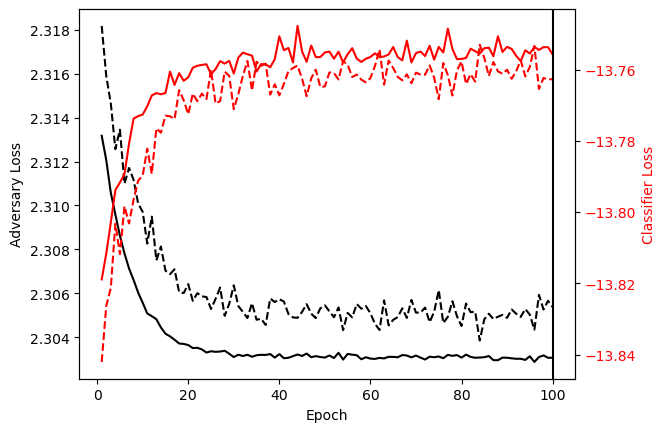

In [472]:
# Training Losses

fig, ax1 = plt.subplots()

best_epoch = np.argmin(diff_scores)+1



ax1.plot(np.arange(len(Training_losses_adv))+1, Training_losses_adv, 'k-', label='Training Adversary')
ax1.plot(np.arange(len(Validation_losses_adv))+1, Validation_losses_adv, 'k--', label='Validation Adversary')

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Adversary Loss', color='k')
ax1.tick_params(axis='y', labelcolor='k')

ax2 = ax1.twinx()

ax2.plot(np.arange(len(Training_losses_clas))+1, Training_losses_clas, 'r-', label='Training Classifier')
ax2.plot(np.arange(len(Validation_losses_clas))+1, Validation_losses_clas, 'r--', label='Validation Classifier')
ax2.axvline(best_epoch,label="Final model stopped here",color='k')

ax2.set_ylabel('Classifier Loss', color='r')
ax2.tick_params(axis='y', labelcolor='r')



Text(0.5, 0, 'Epoch')

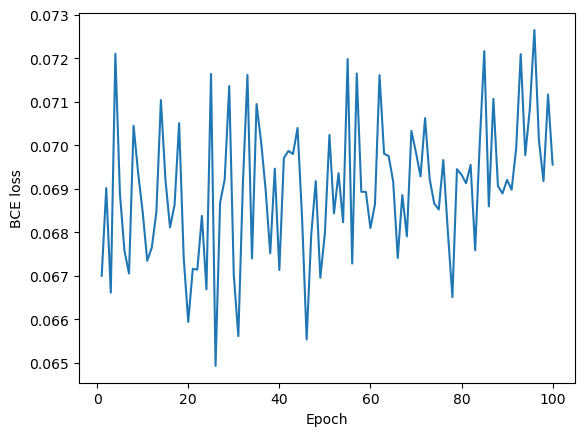

In [473]:
Validation_losses_clas+lambda_*Validation_losses_adv

plt.plot(np.arange(len(Training_losses_adv))+1, Validation_losses_clas+lambda_*Validation_losses_adv)
plt.ylabel("BCE loss")
plt.xlabel('Epoch')

## Test adversarially trained models

Test AUROC: 0.9930


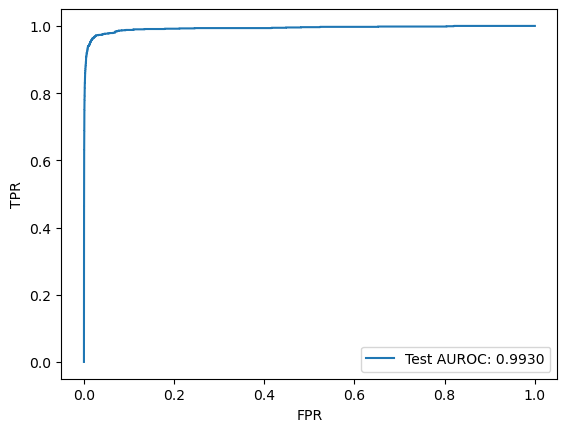

In [474]:
# Now test the pretrained model
test_pred = mytools.test_clas(test_loader, final_clas_adv, device)
test_pred=torch.sigmoid(torch.tensor(test_pred)).numpy()


fpr, tpr, thresholds = sklearn.metrics.roc_curve(y_test, test_pred, pos_label=1)
auc_test = sklearn.metrics.auc(fpr, tpr)
print(f'Test AUROC: {auc_test:0.4f}')

plt.plot(fpr, tpr, label=f'Test AUROC: {auc_test:0.4f}')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()

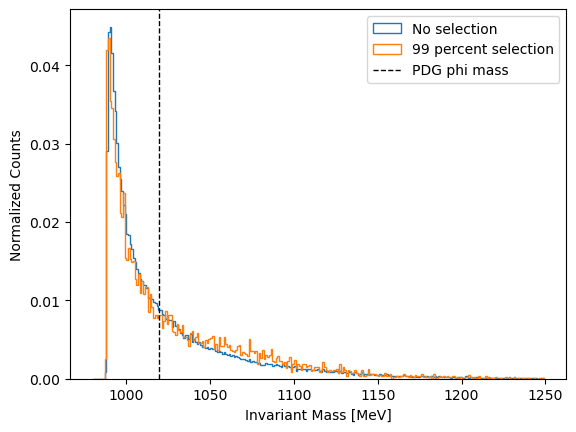

In [475]:
df_test["Class_adv"] = test_pred
df_bkg = df_test.loc[ (df_test.type == 'tritrig') | (df_test.type == 'wab')]
per = np.percentile(df_bkg['Class_adv'],90)
df_cut = df_bkg[df_bkg['Class_adv']>per].reset_index(drop=True)
x_vals = 1000*df_cut.InvM

plt.figure()
plt.hist(1000*df_bkg.InvM, bins=np.arange(980,1250,1), histtype='step', label='No selection', density=True)
plt.hist(x_vals, bins=np.arange(980,1250,1), histtype='step', label= '99 percent selection', density=True)
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Normalized Counts')
plt.legend()

In [476]:

x1 = 1000* df_bkg.InvM.values
x2 = 1000*df_cut.InvM.values

N, edges = np.histogram(x1, bins=np.arange(980,1250,1), density=False)
M, edges = np.histogram(x2, bins=np.arange(980,1250,1), density=False)

N2 = N[(N > 0) & (M > 0)]
M2 = M[(N > 0) & (M > 0)]

diff_score = np.mean(np.abs(N2/np.sum(N)-M2/np.sum(M)) / (np.sqrt(N2)/np.sum(N) + np.sqrt(M2)/np.sum(M) ))

print(diff_score)

N = len(df_test.loc[ ((df_test.type == 'tritrig') | (df_test.type == 'wab')) & (df_test.InvM < (1.019 + 0.01) )  & (df_test.InvM > (1.019 - 0.01) ) & ( df_test['Class_adv']>per ) ] )
S = len(df_test.loc[ (df_test.type == 'phiKK') & (df_test.InvM < (1.019 + 0.01) )  & (df_test.InvM > (1.019 - 0.01) ) & ( df_test['Class_adv']>per )  ] )

print(S/N)

0.8497390522225555
0.5770089285714286


Test AUROC: 0.9930


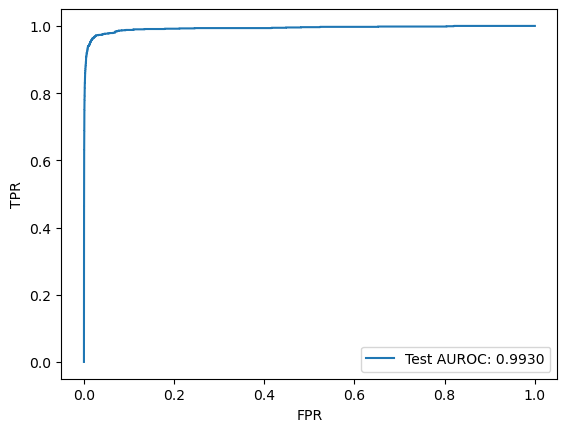

In [477]:
# Now test the pretrained model
test_pred = mytools.test_clas(test_loader, final_classifier, device)
test_pred=torch.sigmoid(torch.tensor(test_pred)).numpy()


fpr, tpr, thresholds = sklearn.metrics.roc_curve(y_test, test_pred, pos_label=1)
auc_test = sklearn.metrics.auc(fpr, tpr)
print(f'Test AUROC: {auc_test:0.4f}')

plt.plot(fpr, tpr, label=f'Test AUROC: {auc_test:0.4f}')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()

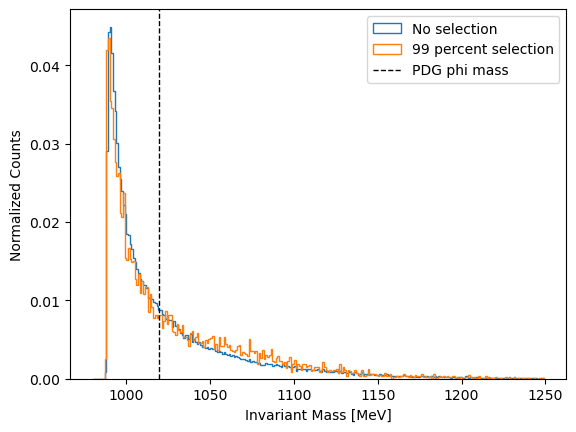

In [478]:
df_test["Class_adv"] = test_pred
df_bkg = df_test.loc[ (df_test.type == 'tritrig') | (df_test.type == 'wab')]
per = np.percentile(df_bkg['Class_adv'],90)
df_cut = df_bkg[df_bkg['Class_adv']>per].reset_index(drop=True)
x_vals = 1000*df_cut.InvM

plt.figure()
plt.hist(1000*df_bkg.InvM, bins=np.arange(980,1250,1), histtype='step', label='No selection', density=True)
plt.hist(x_vals, bins=np.arange(980,1250,1), histtype='step', label= '99 percent selection', density=True)
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Normalized Counts')
plt.legend()

In [479]:

x1 = 1000* df_bkg.InvM.values
x2 = 1000*df_cut.InvM.values

N, edges = np.histogram(x1, bins=np.arange(980,1250,1), density=False)
M, edges = np.histogram(x2, bins=np.arange(980,1250,1), density=False)

N2 = N[(N > 0) & (M > 0)]
M2 = M[(N > 0) & (M > 0)]

diff_score = np.mean(np.abs(N2/np.sum(N)-M2/np.sum(M)) / (np.sqrt(N2)/np.sum(N) + np.sqrt(M2)/np.sum(M) ))

print(diff_score)

N = len(df_test.loc[ ((df_test.type == 'tritrig') | (df_test.type == 'wab')) & (df_test.InvM < (1.019 + 0.01) )  & (df_test.InvM > (1.019 - 0.01) ) & ( df_test['Class_adv']>per ) ] )
S = len(df_test.loc[ (df_test.type == 'phiKK') & (df_test.InvM < (1.019 + 0.01) )  & (df_test.InvM > (1.019 - 0.01) ) & ( df_test['Class_adv']>per )  ] )

print(S/N)

0.8497390522225555
0.5770089285714286


In [480]:
# Save the adversarially trained models
#torch.save(final_clas_adv.state_dict(), "/Users/mghrear/data/ML_data/patch/classifier_adv_2021_v9_pass5_run"+str(run)+"_limited.pt")
#torch.save(final_adv_adv.state_dict(), "/Users/mghrear/data/ML_data/patch/adversary_adv_2021_v9_pass5_run"+str(run)+"_limited.pt")